# Ironman Race Results Analysis

This notebook demonstrates how to scrape, clean, analyze, and visualize Ironman race results. The workflow includes data extraction, cleaning, transformation, analysis, and visualization of performance trends.

In [20]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup
import re
import os
# Load all sheets from the Excel file into separate DataFrames

def load_ironman_sheets(excel_path):
    """
    Load all sheets from the Ironman Excel file into a dictionary of DataFrames.
    Drops the sheet named 'hiddensheet' if present.
    Returns: dict of {sheet_name: DataFrame}
    """
    all_sheets = pd.read_excel(excel_path, sheet_name=None)
    if 'hiddenSheet' in all_sheets:
        print("Dropping sheet: hiddenSheet")
        all_sheets.pop('hiddenSheet')
    for name, df in all_sheets.items():
        print(f"Loaded sheet: {name} (rows: {len(df)})")
    return all_sheets

# Usage example:
im_excel_path = '../data/Ironman_RaceResults.xlsx'
im_sheets = load_ironman_sheets(im_excel_path)


imhalf_excel_path = '../data/Ironman70.3_RaceResults.xlsx'
imhalf_sheets = load_ironman_sheets(imhalf_excel_path)
imhalf_sheets.keys()

c:\Users\jhigh\Projects\triathlon-db\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


Dropping sheet: hiddenSheet
Loaded sheet: IM Lake Placid (rows: 3791)
Loaded sheet: IM Arizona (rows: 3059)
Loaded sheet: IM Chattanooga (rows: 2855)
Loaded sheet: IM Texas (rows: 5994)


c:\Users\jhigh\Projects\triathlon-db\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


Dropping sheet: hiddenSheet
Loaded sheet: IM703 Eagleman (rows: 5414)
Loaded sheet: IM703 Oceanside (rows: 7179)
Loaded sheet: IM703 Boulder (rows: 4808)
Loaded sheet: IM703 Chattanooga (rows: 8829)
Loaded sheet: IM703 Indian Wells (rows: 4367)
Loaded sheet: IM703 Oregon (rows: 4499)
Loaded sheet: IM703 Santa Cruz (rows: 4157)
Loaded sheet: IM703 Texas (rows: 5057)
Loaded sheet: IM703 Maine (rows: 3588)
Loaded sheet: IM703 Wisconsin (rows: 2727)
Loaded sheet: IM703 St George (rows: 5158)


dict_keys(['IM703 Eagleman', 'IM703 Oceanside', 'IM703 Boulder', 'IM703 Chattanooga', 'IM703 Indian Wells', 'IM703 Oregon', 'IM703 Santa Cruz', 'IM703 Texas', 'IM703 Maine', 'IM703 Wisconsin', 'IM703 St George'])

In [21]:
from database import get_engine
from api_handling import fetch_athlete_country_search, fetch_program_ids

engine = get_engine()
athlete = pd.read_sql_table('athlete', engine)
race_results = pd.read_sql_table('race_results', engine)
events = pd.read_sql_table('events', engine)

other_events_path = '../docs/other_event_data.csv'
other_df = pd.read_csv(other_events_path)
event_ids = other_df['event_id'].unique()

#event_id = 184360
#event_name = "2024 World Triathlon Age-Group Championships Torremolinos-Andalucia"
#progs = fetch_program_ids(event_id)

filtered_results = race_results[race_results['event_id'].isin(event_ids)]
events_unique = events.drop_duplicates(subset=['event_id'])

# Merge event_name into filtered_results
filtered_results = filtered_results.merge(
    events_unique[['event_id', 'event_name']],
    on='event_id',
    how='left'
)

filtered_results = filtered_results.merge(
    athlete[['full_name', 'gender']],
    left_on='athlete_full_name', right_on='full_name',
    how='left'
)

filtered_results = filtered_results[['athlete_full_name', 'total_time', 'event_name', 'gender']]
filtered_results = filtered_results.rename(columns={
    'athlete_full_name': 'Contact',
    'event_name': 'Event',
    'total_time': 'Finish Time Formatted',
    'gender': 'Gender'
})

filtered_results

,Contact,Finish Time Formatted,Event,Gender
0,Magnus Elbæk Ditlev,03:09:08,2024 T100 Triathlon World Tour at CLASH Endura...,male
1,Sam Long,03:09:43,2024 T100 Triathlon World Tour at CLASH Endura...,male
2,Mathis Margirier,03:10:08,2024 T100 Triathlon World Tour at CLASH Endura...,male
3,Youri Keulen,03:10:47,2024 T100 Triathlon World Tour at CLASH Endura...,male
4,Alistair Brownlee,03:11:43,2024 T100 Triathlon World Tour at CLASH Endura...,male
...,...,...,...,...
519,Simona Krivankova,07:35:31,2025 World Triathlon Long Distance Championshi...,female
520,Misaki Tanaka,07:45:16,2025 World Triathlon Long Distance Championshi...,female
521,Chloe Sparrow,DNF,2025 World Triathlon Long Distance Championshi...,female
522,Aurelia Boulanger,DNF,2025 World Triathlon Long Distance Championshi...,female


In [22]:
# Step 1+4: Robust CSV reading with encoding fallback, cleaning, and finish time conversion
import os
import pandas as pd
import re

folder_path = "../data/USAT Results for Elite Criteria"
csv_files = [f for f in os.listdir(folder_path) if f.lower().endswith('.csv')]
print(f"Found {len(csv_files)} CSV files.")

FIRST_NAME_COLS = ['first name', 'firstname', 'first', 'given name', 'fname']
LAST_NAME_COLS = ['last name', 'lastname', 'last', 'surname', 'family name', 'lname']
NAME_COLS = ['name', 'athlete', 'athlete name', 'full name']
FINISH_TIME_COLS = [
    'finish time', 'finishtime', 'finish', 'recorded time', 'time', 'total time', 'final time', 'official time', 'net time', 'chip time', 'result time'
]
GENDER_COLS = ['sex', 'gender']
encodings_to_try = ['utf-8', 'cp1252', 'latin1']
encoding_report = {}

def find_column(cols, candidates):
    for c in candidates:
        for col in cols:
            if c in col.lower():
                return col
    return None

def standardize_gender(g):
    if pd.isnull(g):
        return None
    g = str(g).strip().lower()
    if g in ['m', 'male']:
        return 'Male'
    elif g in ['f', 'female']:
        return 'Female'
    else:
        return g

def extract_source_and_year(filename):
    if 'clash' in filename.lower():
        idx = filename.lower().find('clash')
        trimmed = filename[idx:]
        match = re.search(r'(2023|2024|2025)', trimmed)
        year = match.group(1) if match else None
        return trimmed, year
    match = re.search(r'(2023|2024|2025)', filename)
    if match:
        year = match.group(1)
        idx = filename.find(year)
        trimmed = filename[idx:]
        return trimmed, year
    else:
        return filename, None

def time_to_seconds(t):
    if pd.isnull(t) or t.strip() == '' or str(t).lower() in ['nan', 'none']:
        return None
    parts = t.strip().split(':')
    try:
        parts = [int(float(p)) for p in parts]
        if len(parts) == 3:
            return parts[0]*3600 + parts[1]*60 + parts[2]
        elif len(parts) == 2:
            return parts[0]*60 + parts[1]
        elif len(parts) == 1:
            return parts[0]
        else:
            return None
    except Exception:
        return None
    
# Clean USAT event names: strip .csv, - and _ characters
def clean_usat_event_name(name):
    # Remove .csv extension if present
    if name.lower().endswith('.csv'):
        name = name[:-4]
    # Remove dashes and underscores
    name = name.replace('-', '').replace('_', '')
    return name
 
# If you have a DataFrame with USAT event names, apply this function:

cleaned_dfs = []
for file in csv_files:
    file_path = os.path.join(folder_path, file)
    for enc in encodings_to_try:
        try:
            df = pd.read_csv(file_path, encoding=enc)
            encoding_report[file] = enc
            break
        except Exception as e:
            last_error = e
    else:
        print(f"Error reading {file} with all encodings. Last error: {last_error}")
        encoding_report[file] = 'FAILED'
        continue
    cols = df.columns.tolist()
    first_col = find_column(cols, FIRST_NAME_COLS)
    last_col = find_column(cols, LAST_NAME_COLS)
    name_col = find_column(cols, NAME_COLS)
    time_col = find_column(cols, FINISH_TIME_COLS)
    gender_col = find_column(cols, GENDER_COLS)
    # Combine first and last if both exist
    if first_col and last_col:
        df['Contact'] = df[first_col].astype(str).str.strip() + ' ' + df[last_col].astype(str).str.strip()
    elif name_col:
        df['Contact'] = df[name_col].astype(str).str.strip()
    else:
        df['Contact'] = df.iloc[:,0].astype(str).str.strip()
    if time_col:
        df['Finish Time Formatted'] = df[time_col].astype(str).str.strip()
    else:
        df['Finish Time Formatted'] = None
    if gender_col:
        df['Gender'] = df[gender_col].astype(str).str.strip()
        df['Gender'] = df['Gender'].apply(standardize_gender)
    else:
        df['Gender'] = None
    df['Event'] = file
    # Keep only the relevant columns
    df_clean = df[['Contact', 'Finish Time Formatted', 'Gender', 'Event']].copy()
    trimmed, year = zip(*df_clean['Event'].apply(extract_source_and_year))
    df_clean['Event'] = trimmed
    #df_clean['Event'] = df_clean['Event'].apply(clean_usat_event_name)
    df_clean['Year'] = year
    df_clean['FinishSeconds'] = df_clean['Finish Time Formatted'].apply(time_to_seconds)
    cleaned_dfs.append(df_clean)
    #print(f"FinishTime: {time_col if time_col else 'None'}; Gender: {gender_col if gender_col else 'None'}")
    #display(df_clean.head())

# Combine all cleaned DataFrames into one
df_all_usat = pd.concat(cleaned_dfs, ignore_index=True)
df_all_usat['Country'] = 'United States'
print(f"Combined cleaned USAT DataFrame shape: {df_all_usat.shape}")
display(df_all_usat.head())


Found 23 CSV files.
Combined cleaned USAT DataFrame shape: (21230, 7)


,Contact,Finish Time Formatted,Gender,Event,Year,FinishSeconds,Country
0,Donald Brooks (GBR),2:00:10,Male,2023 Pontevedra AG Worlds-Standard-Triathlon.csv,2023,7210.0,United States
1,Arthur Benson,2:04:38,Male,2023 Pontevedra AG Worlds-Standard-Triathlon.csv,2023,7478.0,United States
2,Dylan McMurrer,2:05:47,Male,2023 Pontevedra AG Worlds-Standard-Triathlon.csv,2023,7547.0,United States
3,Audie McRae,2:07:02,Male,2023 Pontevedra AG Worlds-Standard-Triathlon.csv,2023,7622.0,United States
4,Evan DeVincenzo,2:07:23,Male,2023 Pontevedra AG Worlds-Standard-Triathlon.csv,2023,7643.0,United States


In [23]:
# Add Gender and Finish Time (Seconds) Columns

def parse_time_to_seconds(time_str):
    """Convert a time string (e.g., '8:15:30') to seconds."""
    if pd.isnull(time_str):
        return np.nan
    parts = str(time_str).split(':')
    if len(parts) == 3:
        h, m, s = parts
    elif len(parts) == 2:
        h, m, s = 0, parts[0], parts[1]
    else:
        return np.nan
    try:
        return int(h) * 3600 + int(m) * 60 + float(s)
    except Exception:
        return np.nan
    
def extract_year(event_str):
    """Extracts a 4-digit year from the event string."""
    match = re.search(r'(20\d{2})', str(event_str))
    if match:
        return int(match.group(1))
    return np.nan

def infer_gender_from_age_group(age_group):
    """Infer gender from Age Group code (F=Female, M=Male, else Unknown)."""
    if isinstance(age_group, str):
        if age_group.startswith('F'):
            return 'Female'
        elif age_group.startswith('M'):
            return 'Male'
    return 'Unknown'

def add_columns_to_sheets(sheets):
    for sheet_name, df in sheets.items():
        if 'Finish Time Formatted' in df.columns:
            df['FinishSeconds'] = df['Finish Time Formatted'].apply(parse_time_to_seconds)
        if 'Age Group' in df.columns:
            df['Gender'] = df['Age Group'].apply(infer_gender_from_age_group)
        if 'Event' in df.columns:
            df['Year'] = df['Event'].apply(extract_year)
        if {'FinishSeconds', 'Gender', 'Event', 'Year'}.issubset(df.columns):
            # compute minimum finish time per event, year, and gender
            min_times = df.groupby(['Event', 'Year', 'Gender'])['FinishSeconds'].transform('min')
            mask = df['FinishSeconds'] <= min_times * 1.10
            df = df.loc[mask].copy()
            sheets[sheet_name] = df

add_columns_to_sheets(im_sheets)
add_columns_to_sheets(imhalf_sheets)

filtered_results['FinishSeconds'] = filtered_results['Finish Time Formatted'].apply(parse_time_to_seconds)
filtered_results['Year'] = filtered_results['Event'].apply(extract_year)

pre_combined_df = pd.concat(
    list(im_sheets.values()) + list(imhalf_sheets.values()) + [filtered_results],
    ignore_index=True
)


In [24]:
name_country_dict = dict(
    athlete
    .drop_duplicates(subset=['full_name'])[['full_name','country']]
    .values
)
pre_combined_df['Country'] = pre_combined_df['Contact'].map(name_country_dict)
pre_combined_df['Gender'] = pre_combined_df['Gender'].str.title()

missing_names = pre_combined_df.loc[pre_combined_df['Country'].isna(), 'Contact'].unique()
for name in missing_names:
    try:
        country = fetch_athlete_country_search(name)
    except Exception as e:
        #print(f"Error fetching country for {name}: {e}")
        country = None
    pre_combined_df.loc[pre_combined_df['Contact'] == name, 'Country'] = country

# Count how many Country entries are null
null_count = pre_combined_df['Country'].isna().sum()
print(f"Number of missing country values: {null_count}")

Number of missing country values: 698


In [25]:
combined_df = pd.concat([pre_combined_df, df_all_usat], ignore_index=True)

In [26]:
# Calculate number of finishers and capture contacts within 4%–10% of the winner

def get_finishers(df, gender, percent):
    df_g = df[df['Gender'] == gender].copy()
    if df_g.empty or 'FinishSeconds' not in df_g.columns:
        return [], 0
    winner = df_g['FinishSeconds'].min()
    #print(f"Winner): {winner} seconds at event {df_g['Event'].unique()[0]} in {df_g['Year'].unique()[0]}")
    if pd.isnull(winner):
        print(f"No data")
        return [], 0
    cutoff = winner * (1 + percent/100)
    #print(f"Cutoff for {percent}%: {cutoff} seconds")
    mask = (
        (df_g['FinishSeconds'] <= cutoff) &
        ((df_g['Country'] == 'United States') | df_g['Country'].isna())
    )
    #print(f"Found {mask.sum()} finishers within {percent}% of winner at event {df_g['Event'].unique()[0]} in {df_g['Year'].unique()[0]}")
    #print(mask.sum(), "finishers found within", percent, "% of winner at event ")
    quals = df_g.loc[mask, 'Contact'].unique().tolist()
    return quals, len(quals)

def get_finishers_by_event(df):
    results = []
    percentiles = list(range(4, 11))
    for event in df['Event'].dropna().unique():
        df_e = df[df['Event'] == event]
        for yr in sorted(df_e['Year'].dropna().unique()):
            df_y = df_e[df_e['Year'] == yr]
            for g in ['Male','Female']:
                for pct in percentiles:
                    contacts, cnt = get_finishers(df_y, g, pct)
                    results.append({
                        'Event': event,
                        'Year': int(yr),
                        'Gender': g,
                        'Percent': pct,
                        'NumFinishers': cnt,
                        'Contacts': contacts
                    })
    return pd.DataFrame(results)

# Run it on the combined_df:
results_df = get_finishers_by_event(combined_df)


Summary Table for 2023 IRONMAN Lake Placid (2023)
Male Winner: Joe Skipper, Winning Time: 8:03:46
Female Winner: Alice Alberts, Winning Time: 9:16:01

Summary Table for 2024 IRONMAN Lake Placid (2024)
Male Winner: Trevor Foley, Winning Time: 7:55:23
Female Winner: Danielle Lewis, Winning Time: 9:01:54

Summary Table for 2023 IRONMAN Arizona (2023)
Male Winner: John Dzierzbicki, Winning Time: 8:17:01
Female Winner: Maggie Walsh, Winning Time: 9:33:48

Summary Table for 2024 IRONMAN Arizona (2024)
Male Winner: Zachary Bernier-Michaud, Winning Time: 8:11:06
Female Winner: Amelia Zwiener-Bray, Winning Time: 9:49:08

Summary Table for 2023 IRONMAN Chattanooga (2023)
Male Winner: Fernando Maluf, Winning Time: 8:22:55
Female Winner: Kristen Larue, Winning Time: 10:20:30

Summary Table for 2024 IRONMAN Chattanooga (2024)
Male Winner: Sam Long, Winning Time: 6:32:11
Female Winner: Sarah True, Winning Time: 7:17:13

Summary Table for 2023 IRONMAN Texas (2023)
Male Winner: Rudy Von Berg, Winning

C:\Users\jhigh\AppData\Local\Temp\ipykernel_6180\3635459169.py:39: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6, 4))



Summary Table for 2023 IRONMAN 70.3 Indian Wells La Quinta (2023)
Male Winner: Casper Stornes, Winning Time: 3:38:59
Female Winner: Solveig Løvseth, Winning Time: 4:08:24

Summary Table for 2024 IRONMAN 70.3 Indian Wells La Quinta (2024)
Male Winner: Morgan Pearson, Winning Time: 3:42:26
Female Winner: Claire Michel, Winning Time: 4:10:59

Summary Table for 2023 IRONMAN 70.3 Oregon (2023)
Male Winner: Lionel Sanders, Winning Time: 3:33:37
Female Winner: Danielle Lewis, Winning Time: 3:59:41

Summary Table for 2024 IRONMAN 70.3 Oregon (2024)
Male Winner: Luke Tasker, Winning Time: 3:53:00
Female Winner: Maia Watson, Winning Time: 4:12:51

Summary Table for 2023 IRONMAN 70.3 Santa Cruz (2023)
Male Winner: Tom De Bruyn, Winning Time: 4:02:01
Female Winner: Anna Guzman, Winning Time: 4:35:44

Summary Table for 2024 IRONMAN 70.3 Santa Cruz (2024)
Male Winner: Sebastian Radilla, Winning Time: 4:01:30
Female Winner: Serena Xue, Winning Time: 4:47:22

Summary Table for 2023 IRONMAN 70.3 Texas

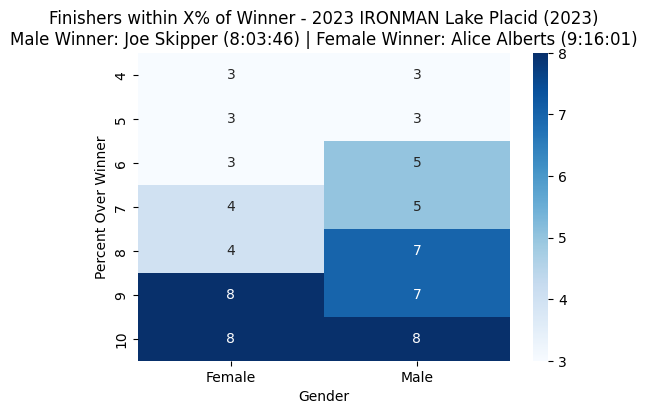

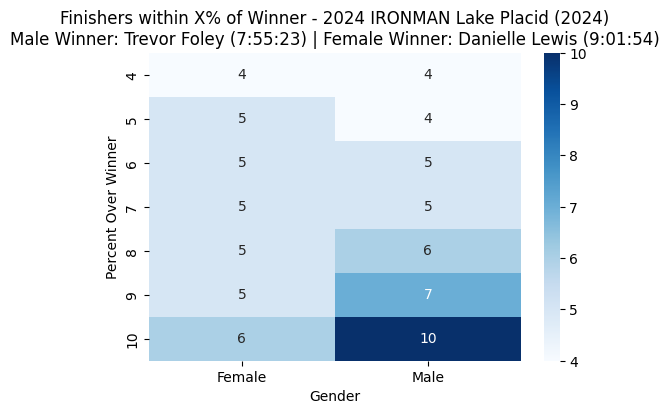

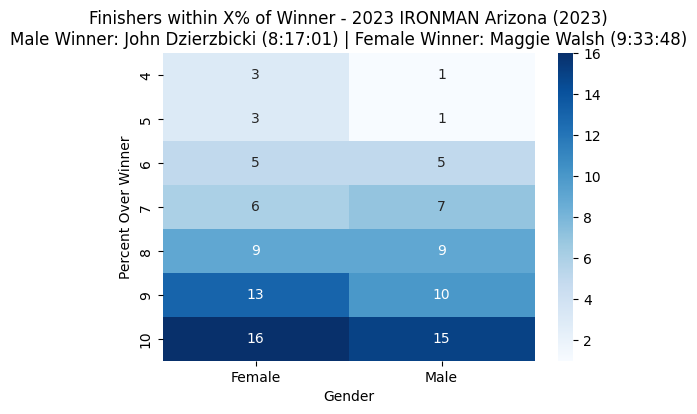

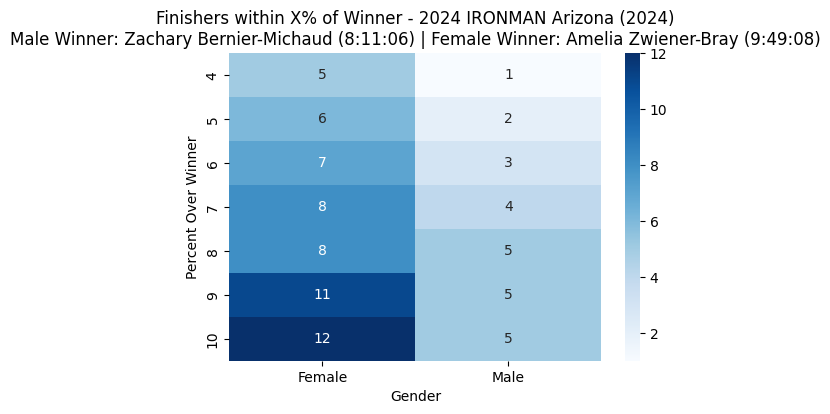

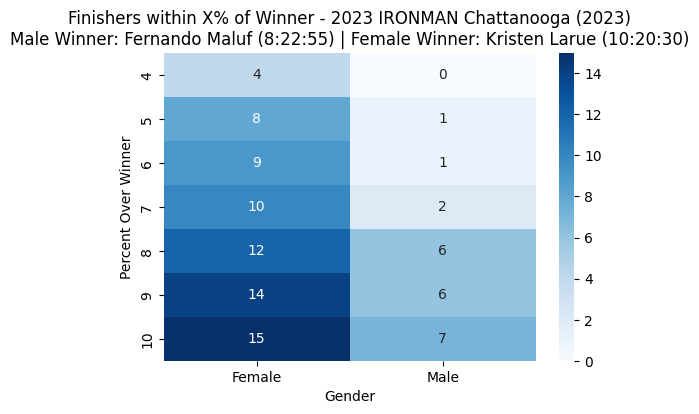

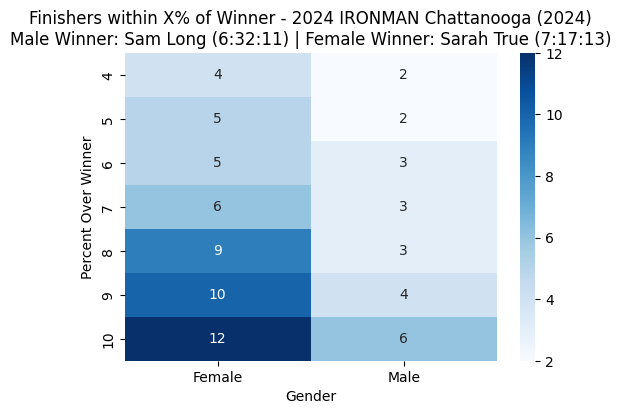

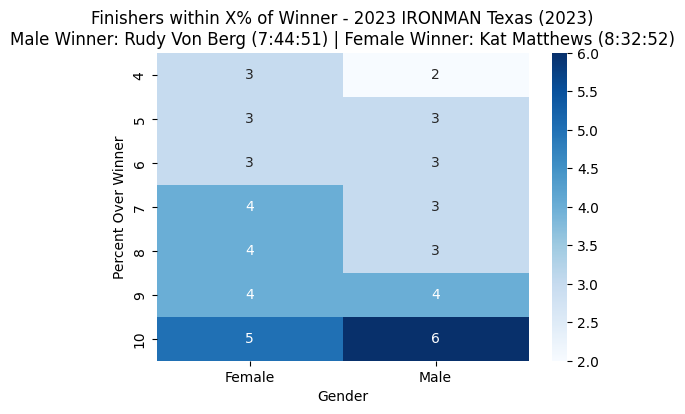

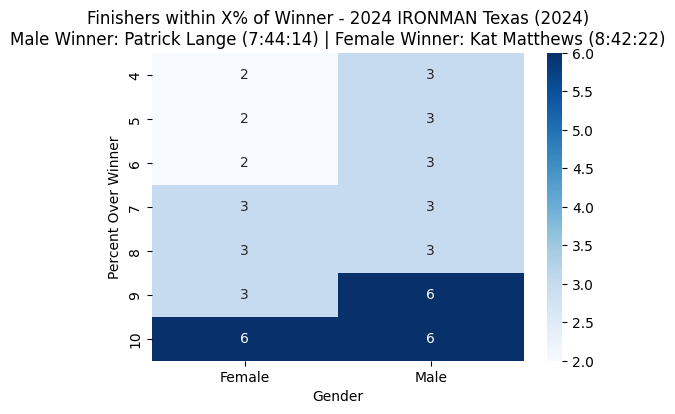

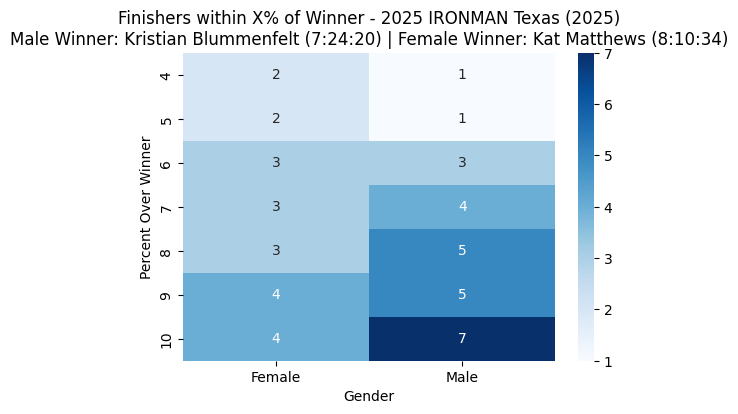

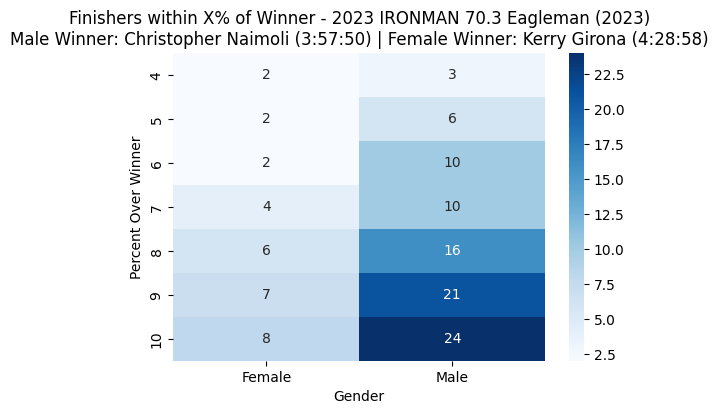

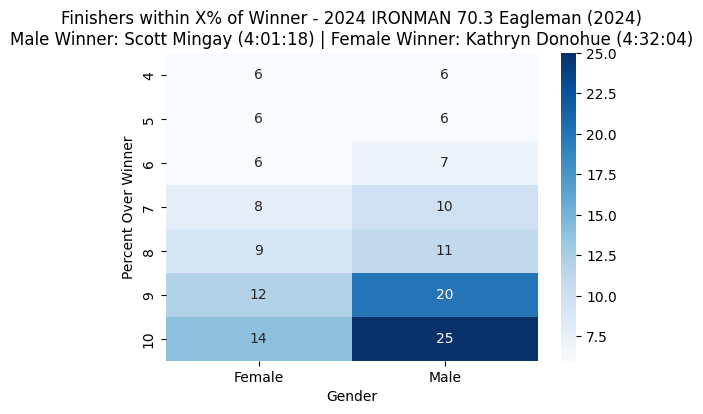

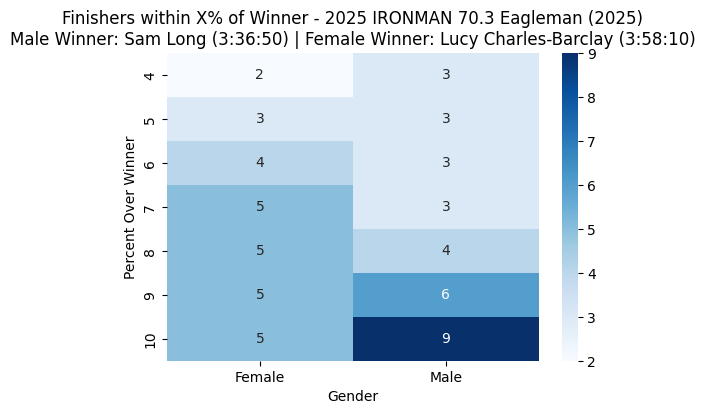

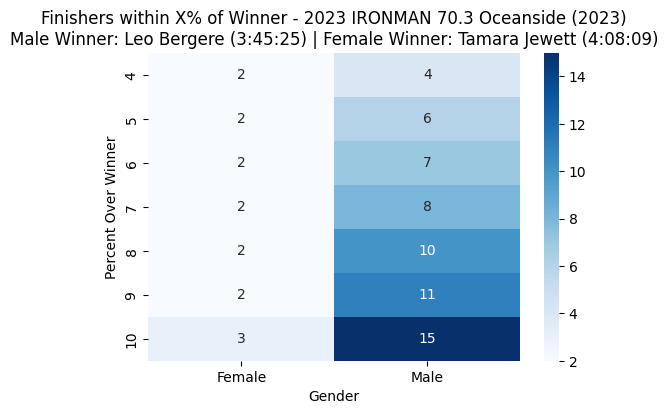

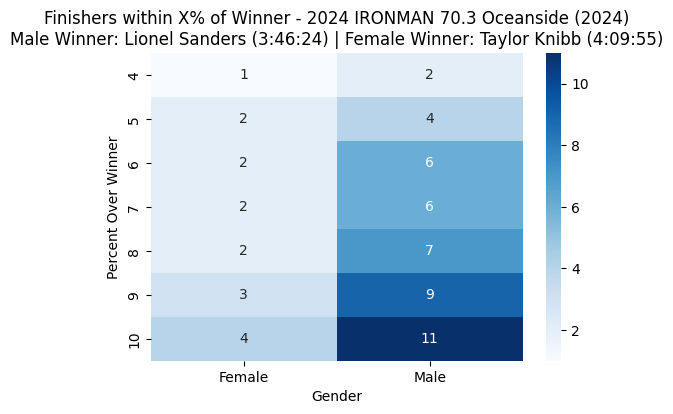

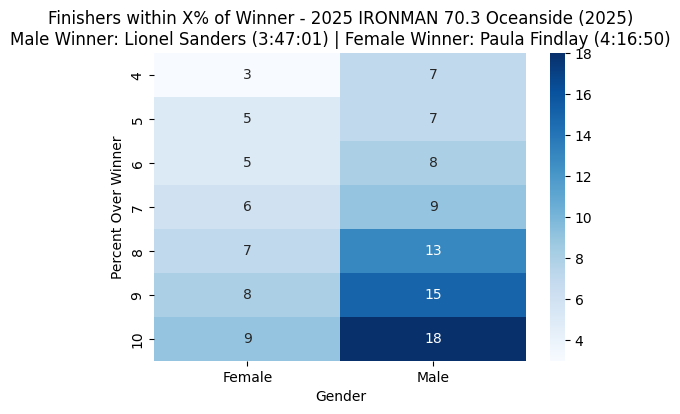

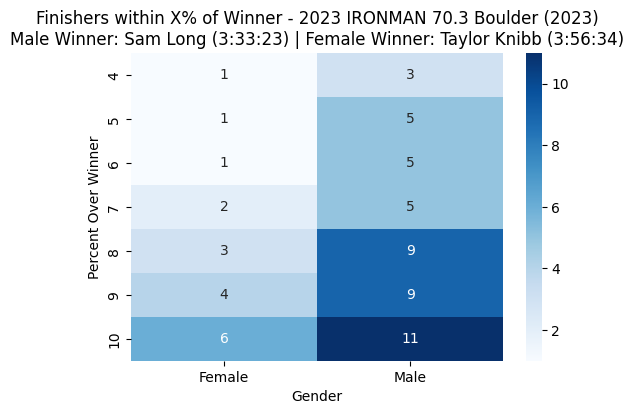

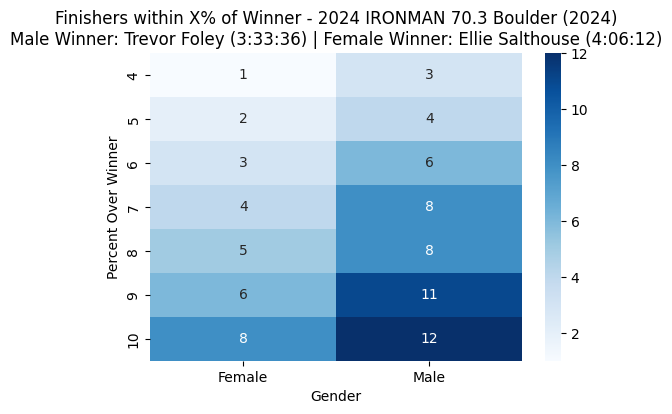

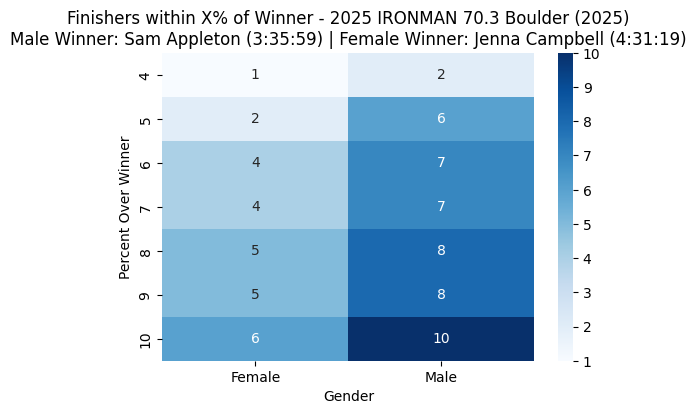

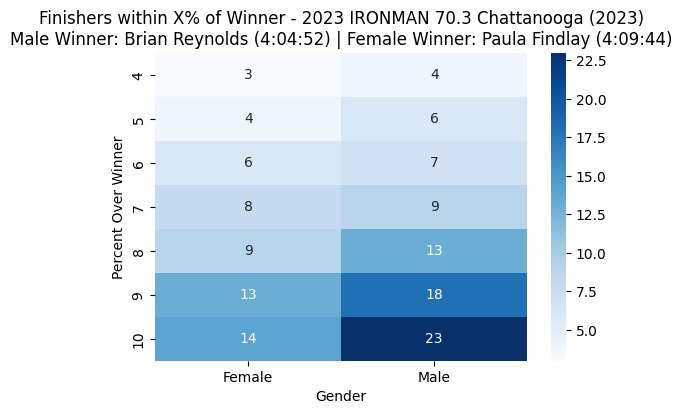

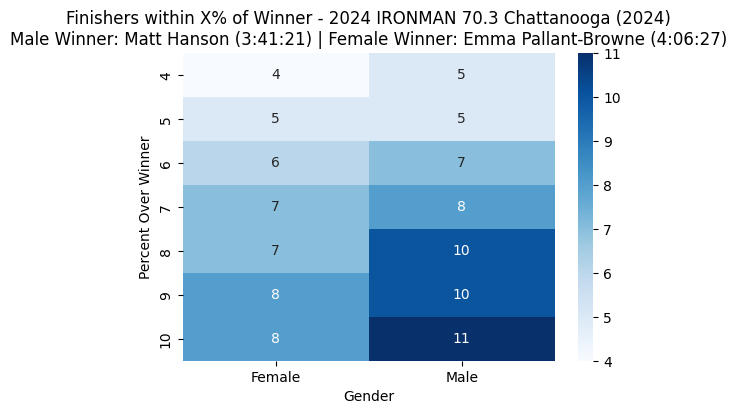

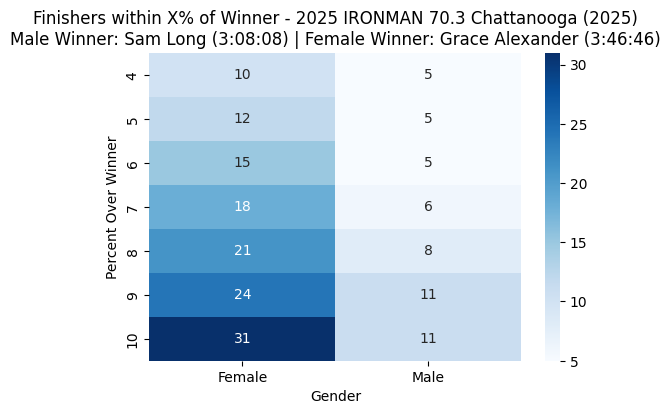

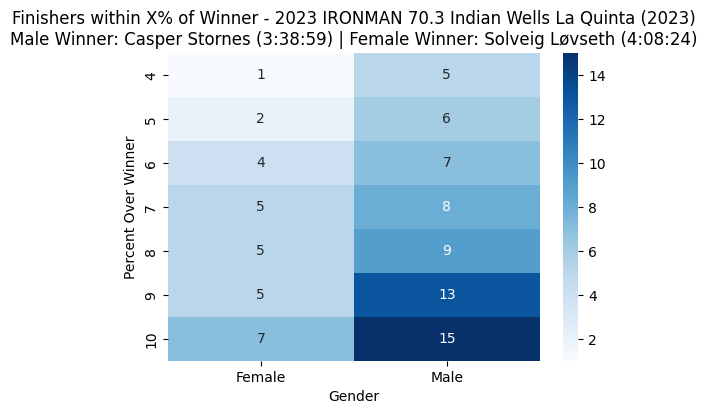

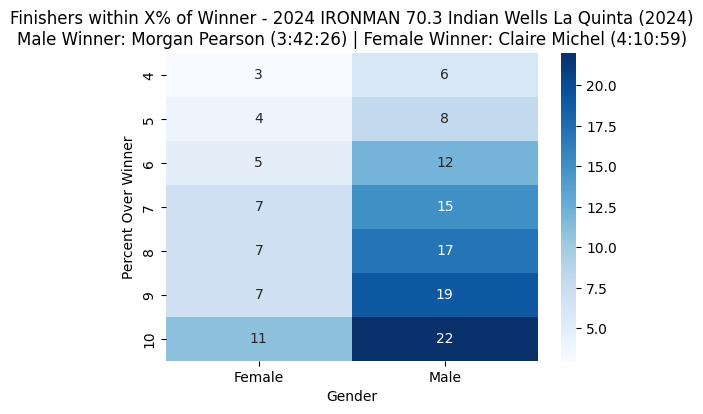

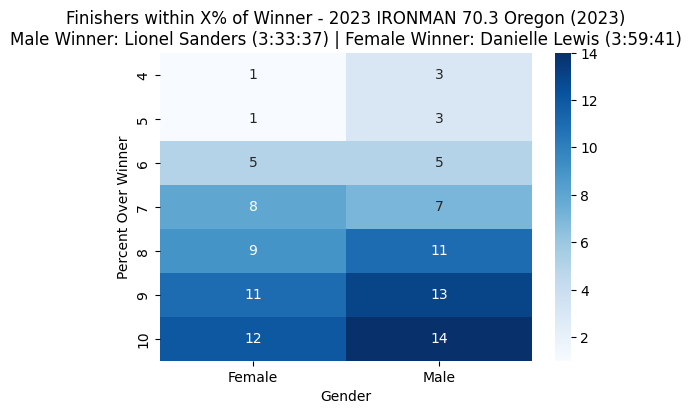

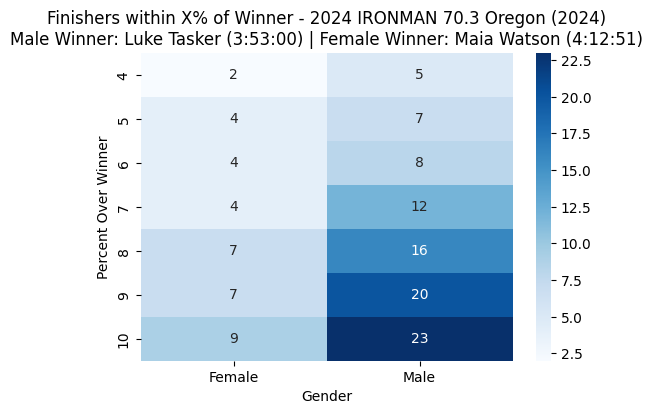

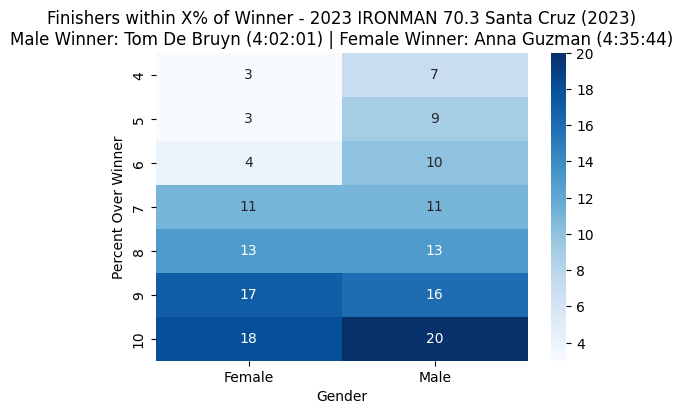

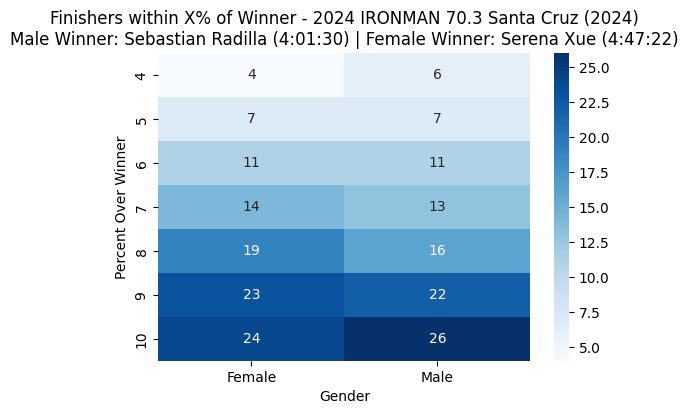

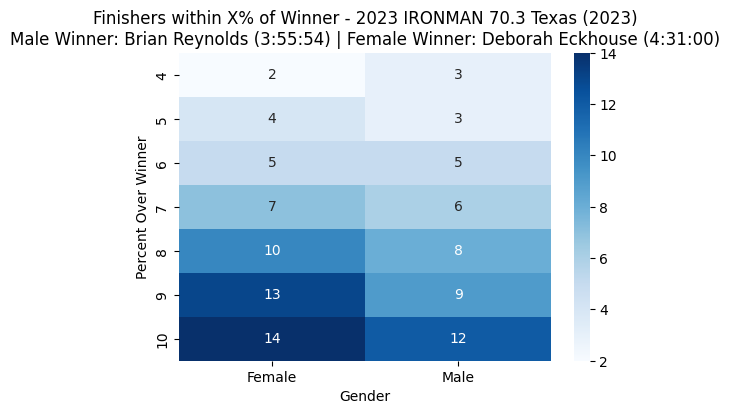

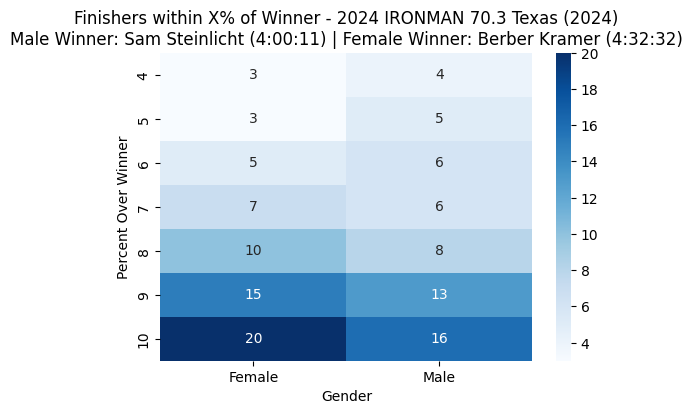

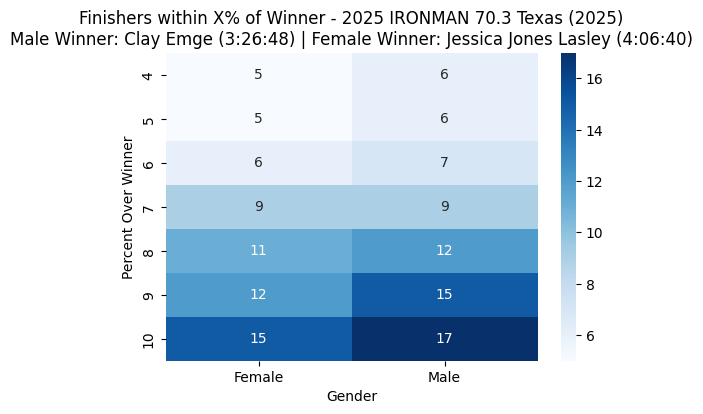

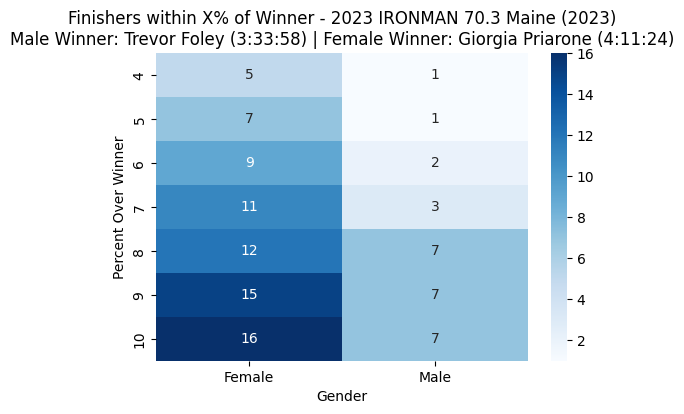

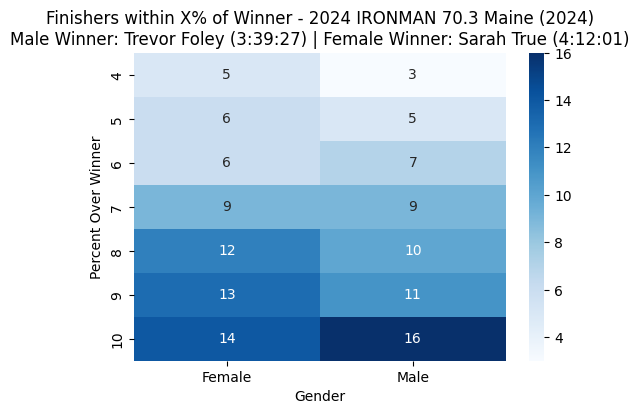

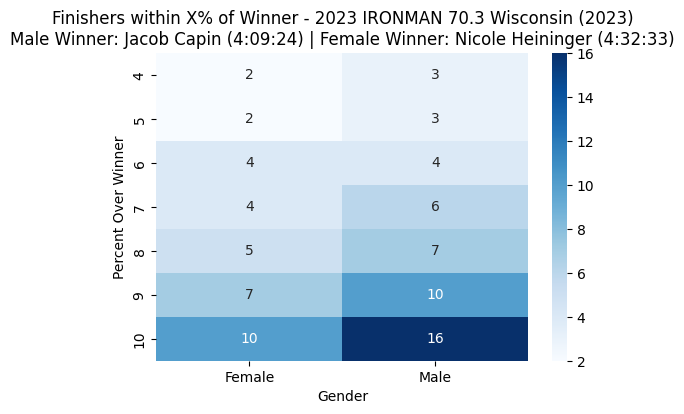

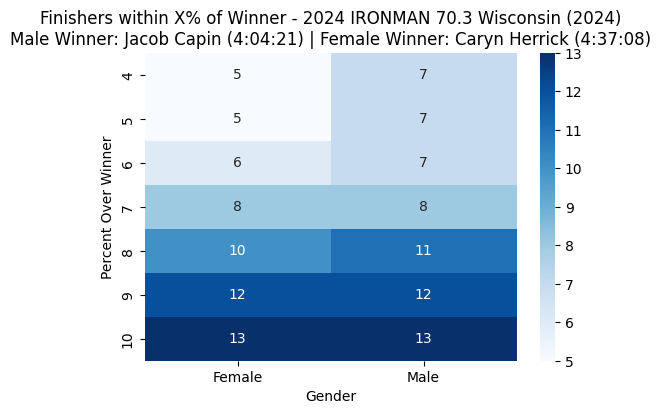

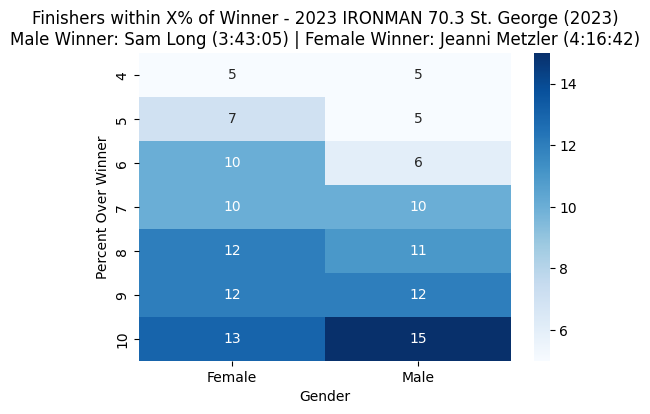

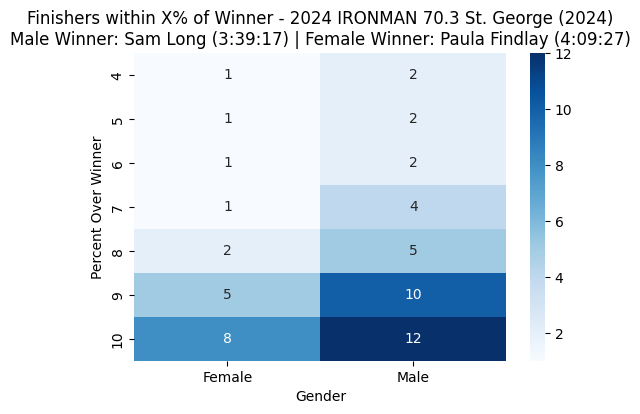

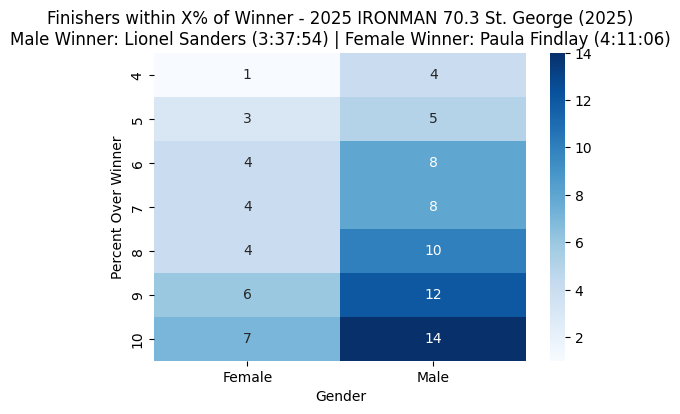

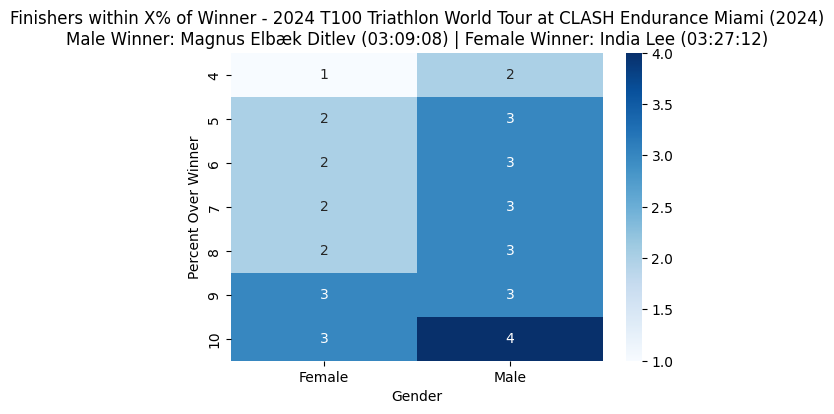

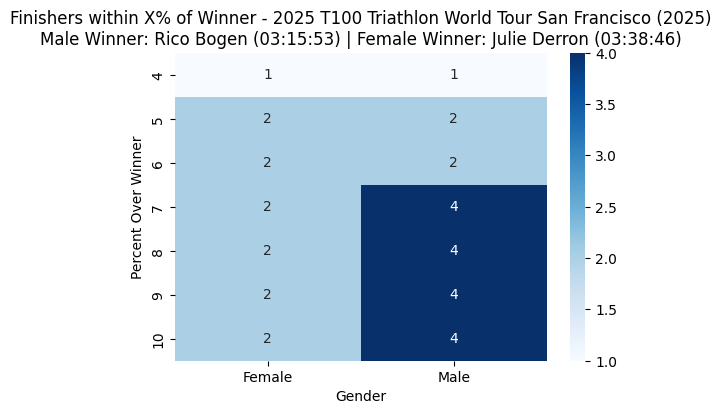

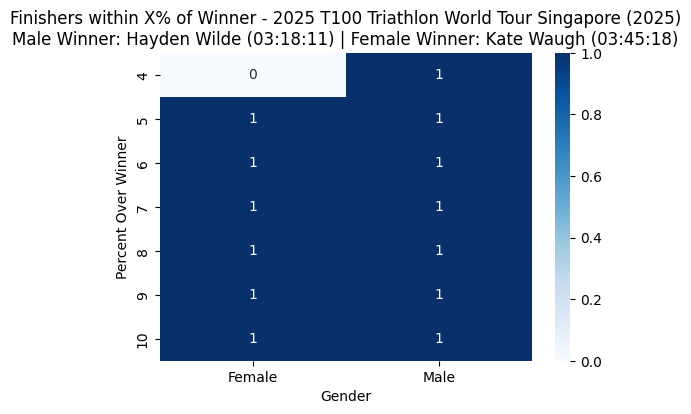

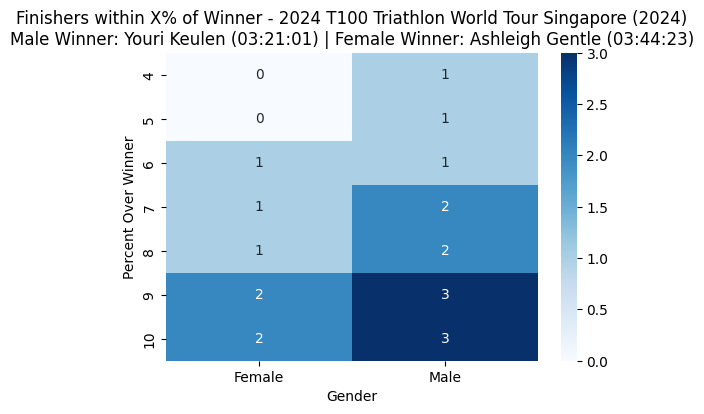

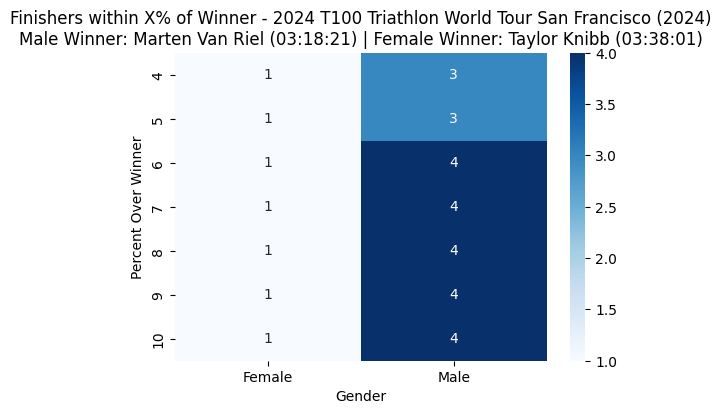

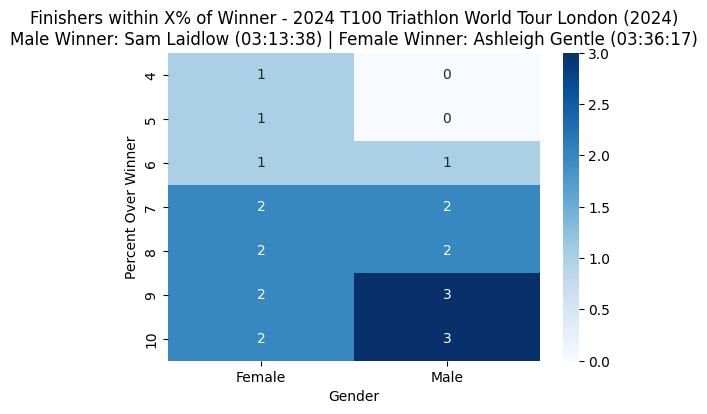

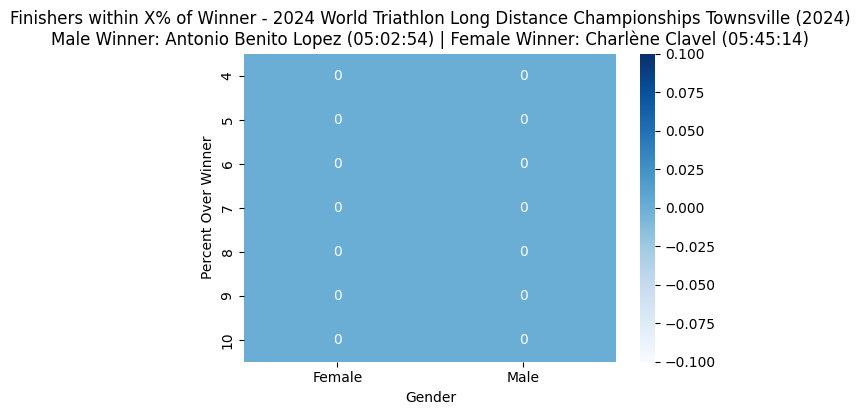

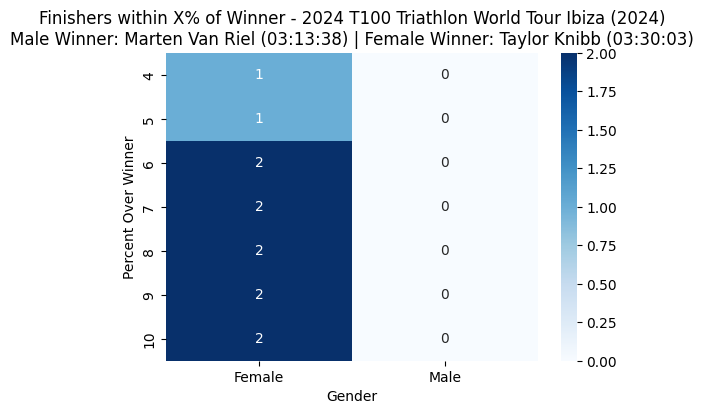

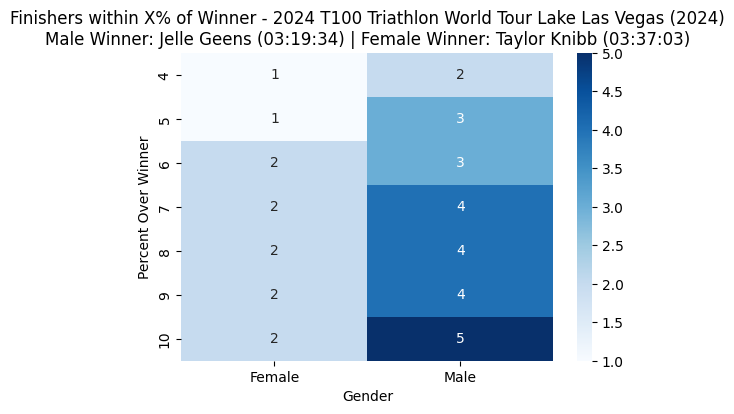

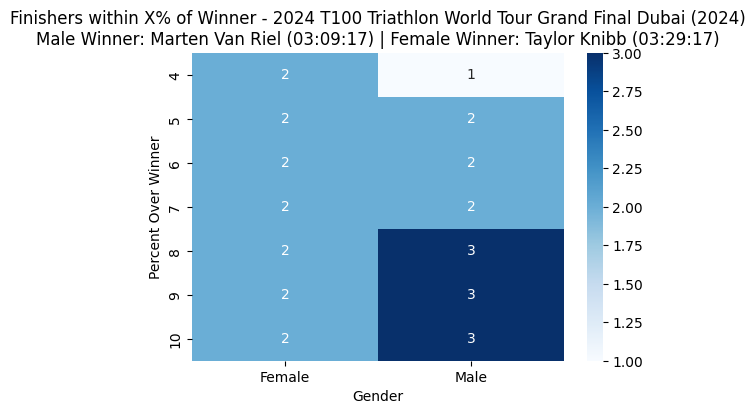

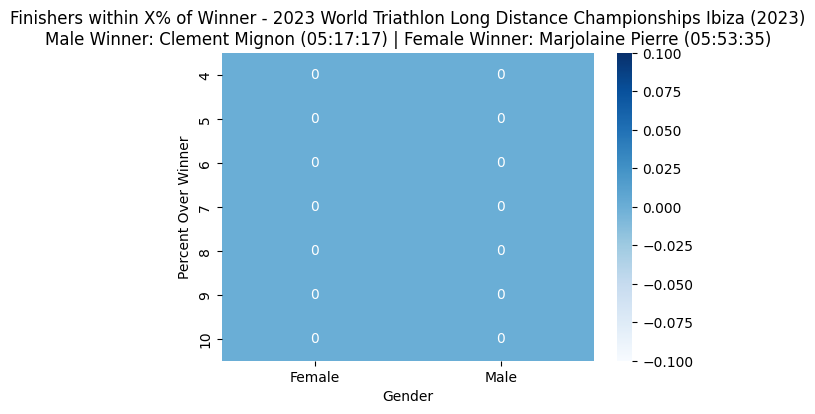

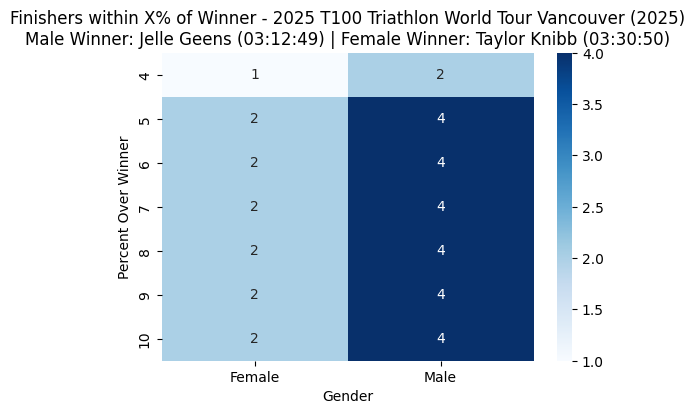

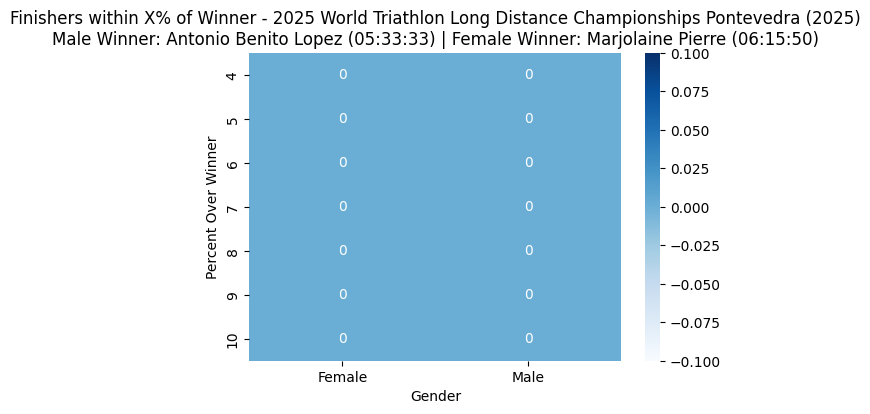

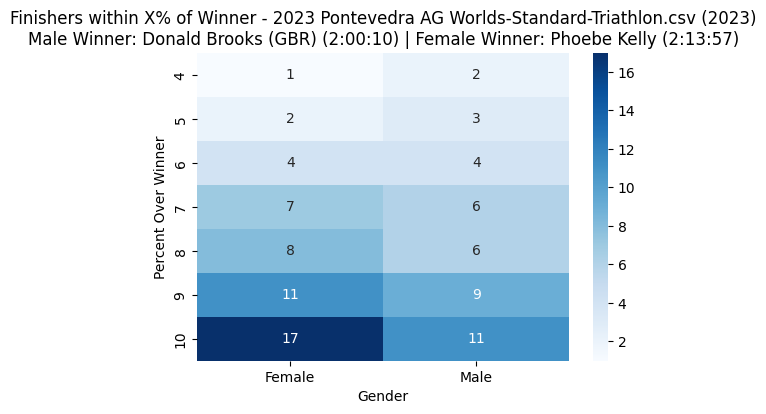

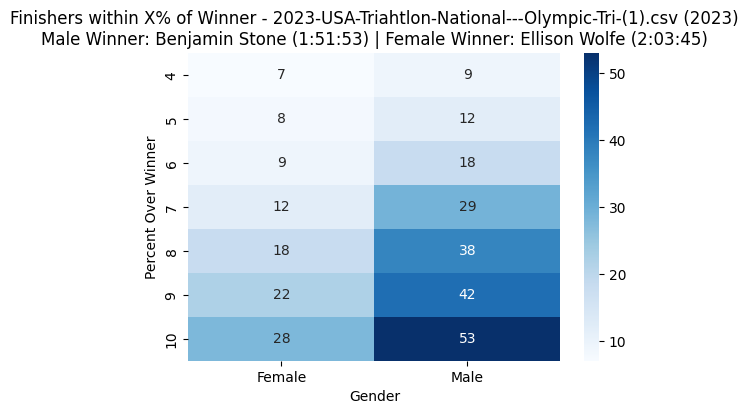

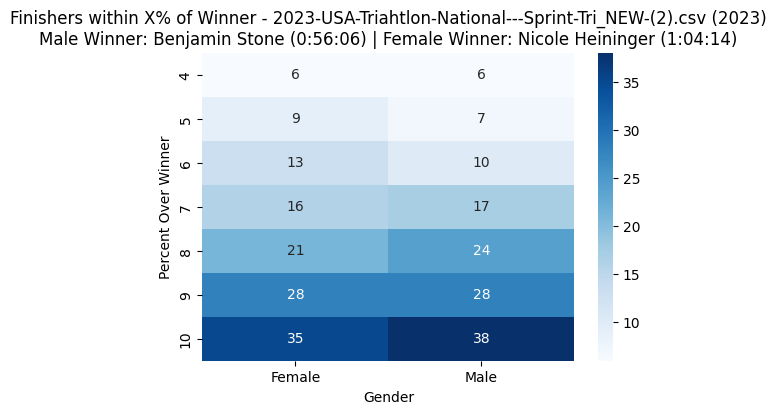

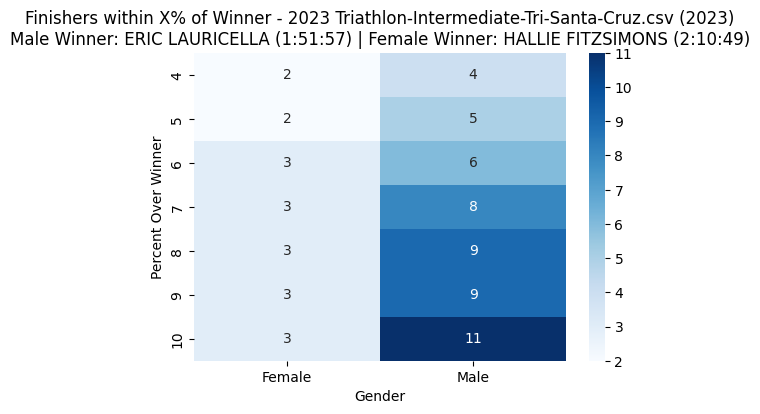

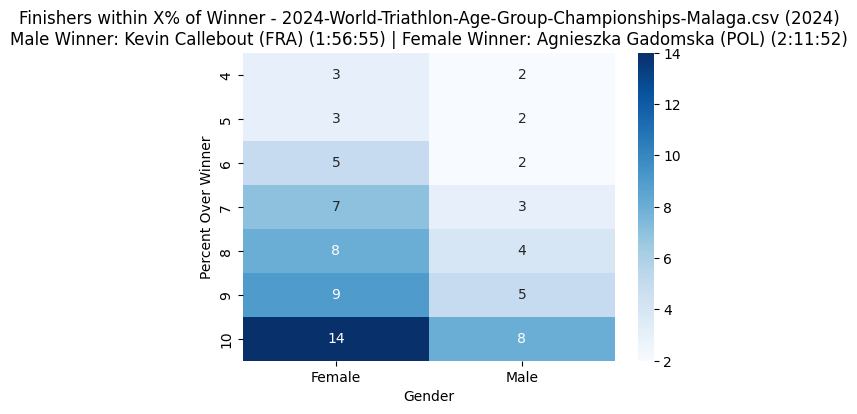

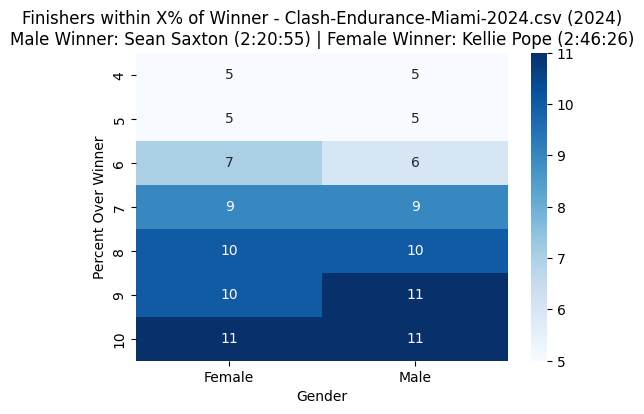

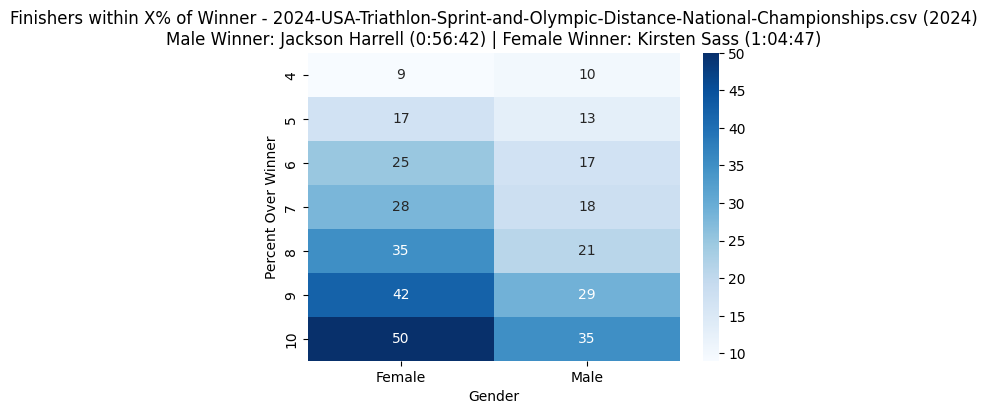

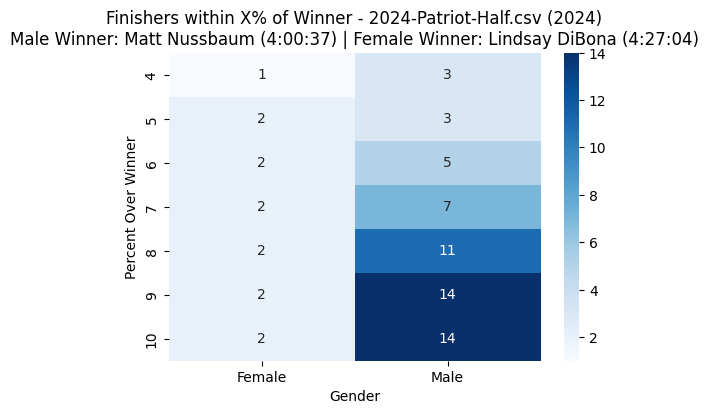

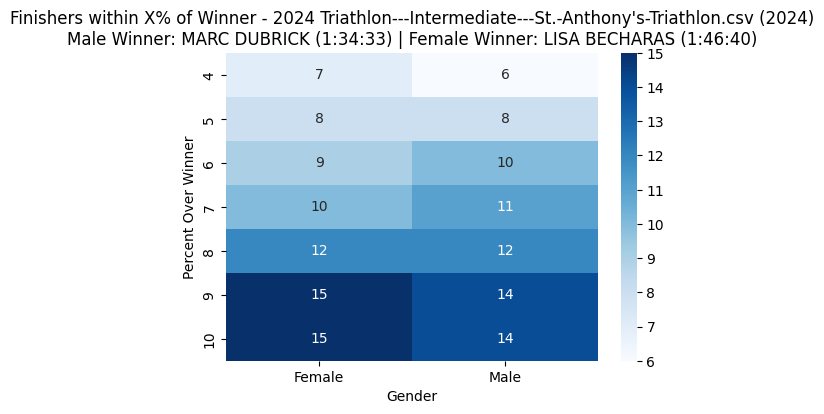

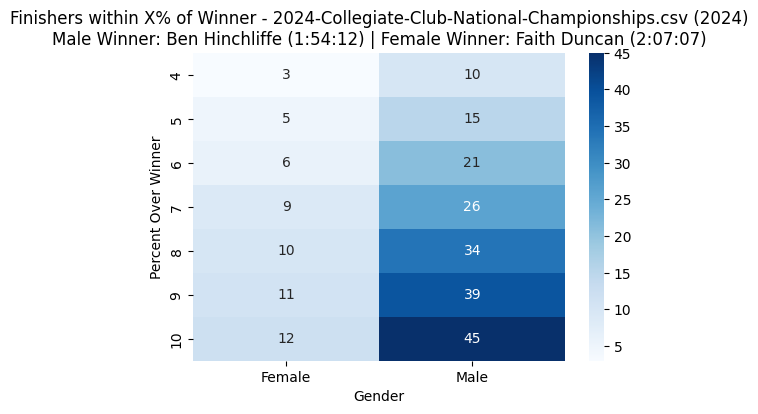

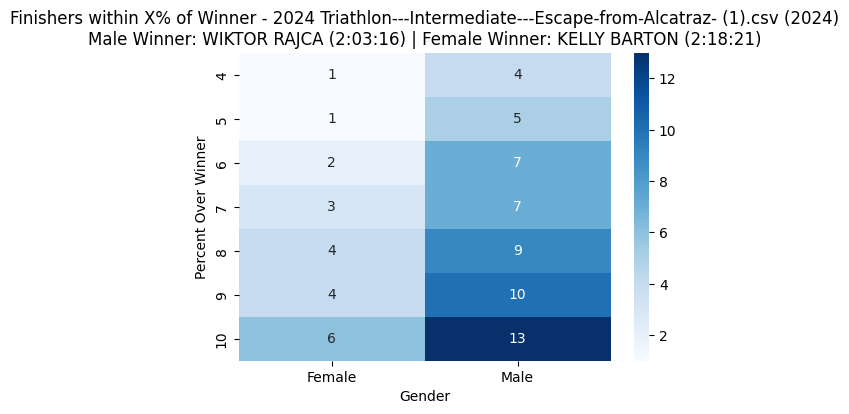

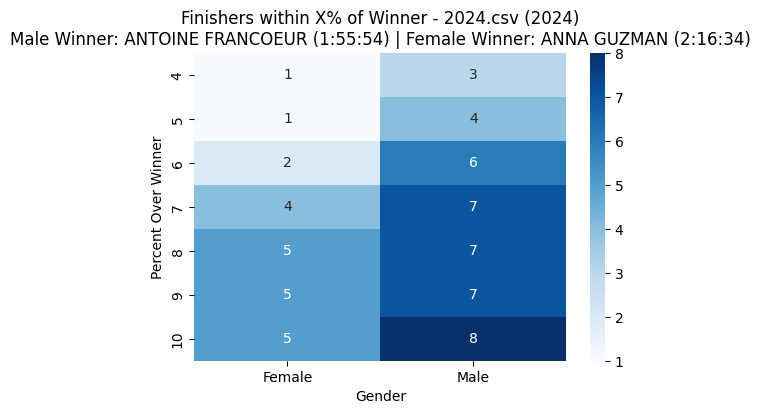

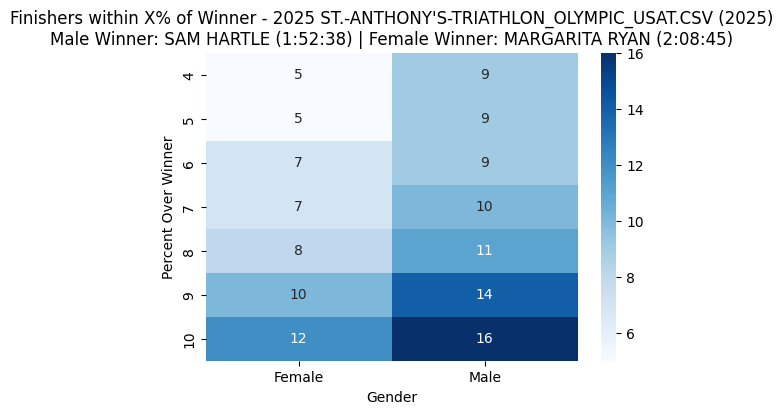

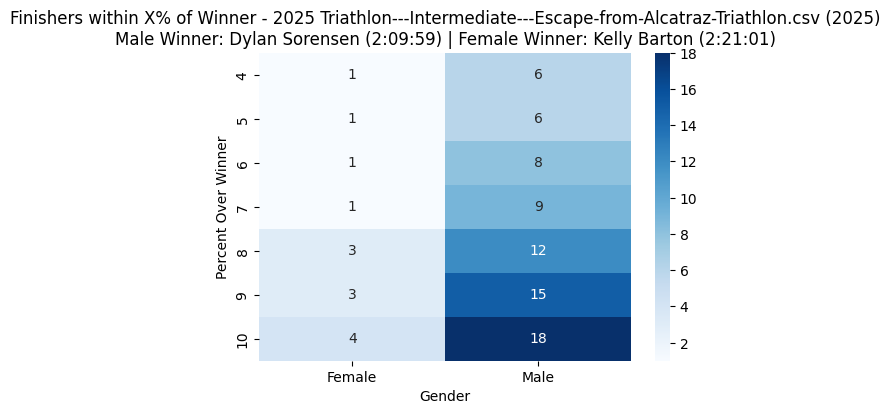

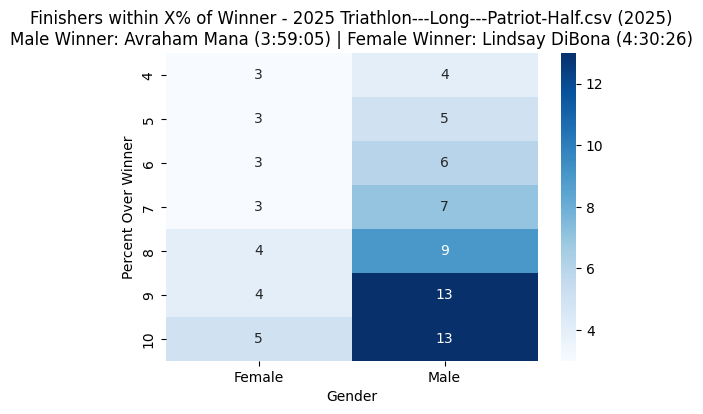

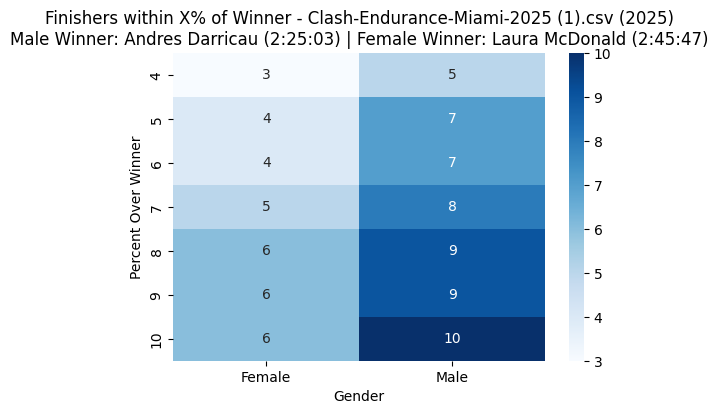

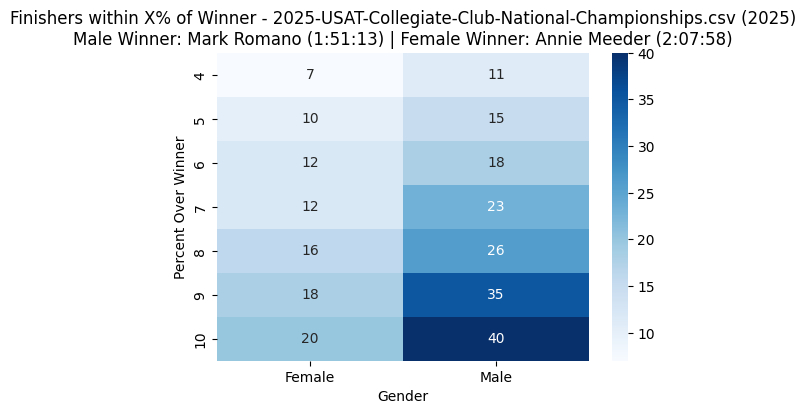

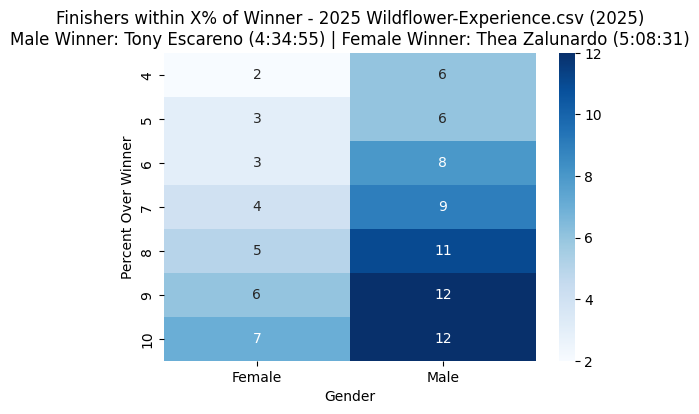

In [41]:
# Visualize and summarize by event, year, and gender
for (event, year) in results_df[['Event', 'Year']].drop_duplicates().itertuples(index=False):
    display_df = results_df[(results_df['Event'] == event) & (results_df['Year'] == year)]\
        .pivot(index='Percent', columns='Gender', values='NumFinishers')
    
    winner_info = {}
    for gender in ['Male', 'Female']:
        # Fix: Convert year to string to match the data type in combined_df
        if event in df_all_usat['Event'].unique():
            mask = (
            (combined_df['Event'] == event) &
            (combined_df['Year'] == str(year)) &  # Convert to string
            (combined_df['Gender'] == gender)
        )
        else: 
            mask = (
                (combined_df['Event'] == event) &
                (combined_df['Year'] == year) &
                (combined_df['Gender'] == gender)
            )
        df_event_gender = combined_df[mask]
        if not df_event_gender.empty and 'FinishSeconds' in df_event_gender.columns:
            # Additional check: ensure we have valid finish times
            valid_times = df_event_gender['FinishSeconds'].dropna()
            if len(valid_times) > 0:
                winner_row = df_event_gender.loc[df_event_gender['FinishSeconds'].idxmin()]
                winner_name = winner_row['Contact']
                winning_time = winner_row['Finish Time Formatted']
                winner_info[gender] = (winner_name, winning_time)
            else:
                winner_info[gender] = ('N/A (No valid times)', 'N/A')
        else:
            winner_info[gender] = ('N/A', 'N/A')

    print(f"\nSummary Table for {event} ({year})")
    for gender in ['Male', 'Female']:
        print(f"{gender} Winner: {winner_info[gender][0]}, Winning Time: {winner_info[gender][1]}")
    #display(display_df)
    plt.figure(figsize=(6, 4))
    title_str = (f"Finishers within X% of Winner - {event} ({year})\n"
                 f"Male Winner: {winner_info['Male'][0]} ({winner_info['Male'][1]}) | "
                 f"Female Winner: {winner_info['Female'][0]} ({winner_info['Female'][1]})")
    sns.heatmap(display_df, annot=True, fmt='d', cmap='Blues')
    plt.title(title_str)
    plt.ylabel('Percent Over Winner')
    plt.xlabel('Gender')
    #plt.show()

In [42]:
b_events = [
    '2023 World Triathlon Long Distance Championships Ibiza',
    '2024 World Triathlon Long Distance Championships Townsville',
    '2025 World Triathlon Long Distance Championships Pontevedra',
    '2024 T100 Triathlon World Tour at CLASH Endurance Miami',
    '2024 T100 Triathlon World Tour Grand Final Dubai',
    '2024 T100 Triathlon World Tour Ibiza',
    '2024 T100 Triathlon World Tour Lake Las Vegas',
    '2024 T100 Triathlon World Tour London',
    '2024 T100 Triathlon World Tour San Francisco',
    '2024 T100 Triathlon World Tour Singapore',
    '2025 T100 Triathlon World Tour San Francisco',
    '2025 T100 Triathlon World Tour Singapore',
    '2025 T100 Triathlon World Tour Vancouver',
    'IRONMAN Texas',
    'IRONMAN 70.3 St George'
]
c_events = ['IRONMAN Arizona',
            'IRONMAN Lake Placid',
            'IRONMAN Chattanooga',
            'IRONMAN 70.3 Eagleman',
            'IRONMAN 70.3 Oceanside',
            'IRONMAN 70.3 Boulder',
            'IRONMAN 70.3 Chattanooga',
            'Clash-Endurance-Miami-2024',
            'Clash-Daytona.csv'
            "2024 Triathlon---Intermediate---St.-Anthony's-Triathlon.csv",
            '2023-USA-Triahtlon-National---Olympic-Tri-(1).csv',
            '2023-USA-Triahtlon-National---Sprint-Tri_NEW-(2).csv',
            'Clash-Endurance-Daytona.csv',
            '2024 Triathlon---Intermediate---Escape-from-Alcatraz- (1).csv',
            '2024.csv', "2025 ST.-ANTHONY'S-TRIATHLON_OLYMPIC_USAT.CSV",
            '2025 Triathlon---Intermediate---Escape-from-Alcatraz-Triathlon.csv'
            'Clash-Endurance-Miami-2025 (1).csv',
    
]
d_events = [
    '2024 IRONMAN 70.3 Indian Wells La Quinta',
    'IRONMAN 70.3 Oregon',
    'IRONMAN 70.3 Santa Cruz',
    'IRONMAN 70.3 Texas', 
    'IRONMAN 70.3 Maine',
    'IRONMAN 70.3 Wisconsin',
    '2023 Pontevedra AG Worlds-Standard-Triathlon.csv',
    '308115-Harvest-Moon-Long-Course-Triathlon-Tri.csv',
    '2023 Triathlon-Intermediate-Tri-Santa-Cruz.csv',
    '2024-USA-Triathlon-Sprint-and-Olympic-Distance-National-Championships.csv',
    '2024-Patriot-Half.csv',
    '309064---Triathlon---Intermediate---Chicago-Triathlon.csv',
    '2024-Collegiate-Club-National-Championships.csv',
    '2025 Triathlon---Long---Patriot-Half.csv',
    '2025-USAT-Collegiate-Club-National-Championships.csv',
    '2025 Wildflower-Experience.csv'
]

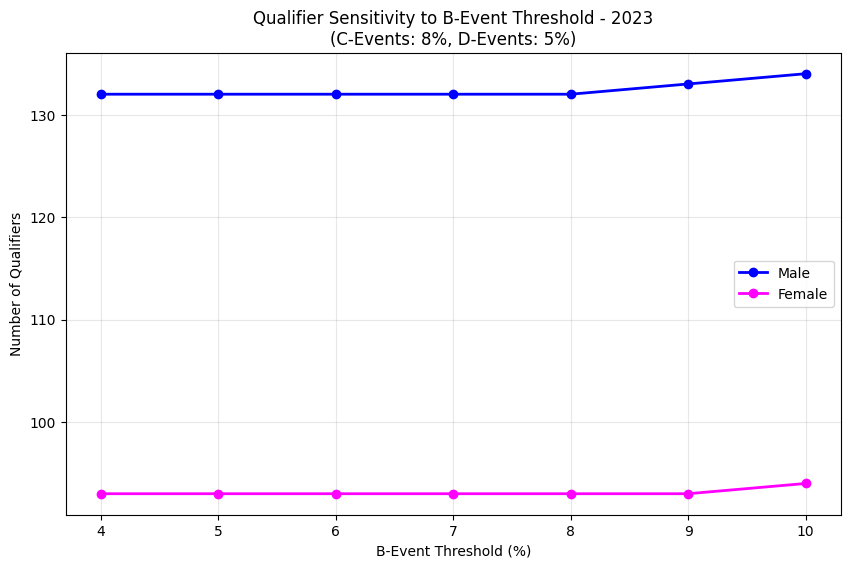

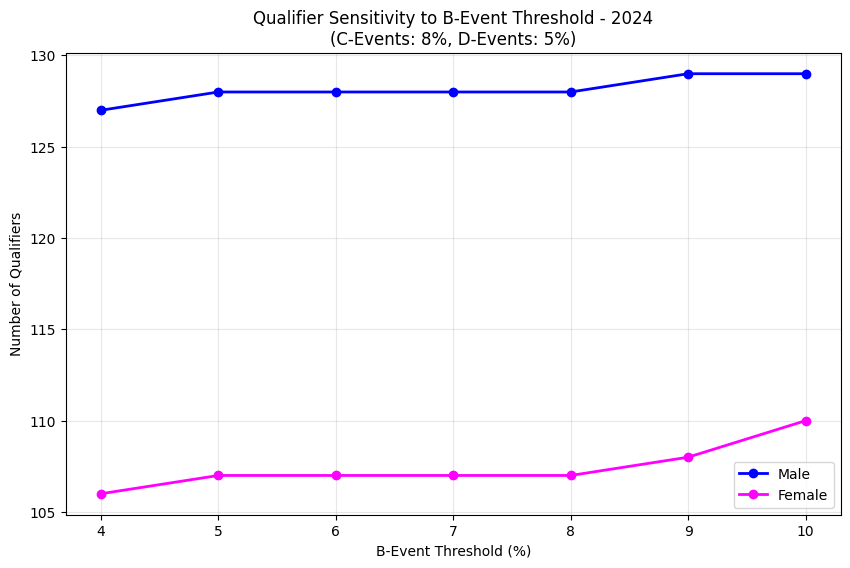

In [43]:
def get_event_category(event_name):
    """Determine if event is b, c, or d category"""
    for e in b_events:
        if e in event_name:
            return 'b'
    for e in c_events:
        if e in event_name:
            return 'c'
    for e in d_events:
        if e in event_name:
            return 'd'
    return None

def count_qualifiers_with_thresholds(results_df, year, b_thresh, c_thresh, d_thresh):
    """Count unique qualifiers for a given year and threshold combination"""
    year_data = results_df[results_df['Year'] == year].copy()
    year_data['EventCategory'] = year_data['Event'].apply(get_event_category)
    
    # Filter out events without category
    year_data = year_data[year_data['EventCategory'].notna()]
    
    qualified_athletes = {'Male': set(), 'Female': set()}
    
    for _, row in year_data.iterrows():
        event_cat = row['EventCategory']
        percent = row['Percent']
        gender = row['Gender']
        contacts = row['Contacts']
        
        # Determine required threshold for this event
        if event_cat == 'b':
            required_thresh = b_thresh
        elif event_cat == 'c':
            required_thresh = c_thresh
        elif event_cat == 'd':
            required_thresh = d_thresh
        else:
            continue
            
        # If this row matches the required threshold, add contacts
        if percent == required_thresh:
            qualified_athletes[gender].update(contacts)
    
    return len(qualified_athletes['Male']), len(qualified_athletes['Female'])

# Chart 1: B-Events Dynamic (C=6%, D=4% fixed)
thresholds = list(range(4, 11))
chart1_data = []

for year in [2023, 2024]:
    for thresh in thresholds:
        male_count, female_count = count_qualifiers_with_thresholds(
            results_df, year, b_thresh=thresh, c_thresh=8, d_thresh=5
        )
        chart1_data.append({
            'Year': year,
            'Threshold': thresh,
            'Male': male_count,
            'Female': female_count,
        })

chart1_df = pd.DataFrame(chart1_data)

# Visualization for Chart 1
for year in [2023, 2024]:
    year_data = chart1_df[chart1_df['Year'] == year]
    
    plt.figure(figsize=(10, 6))
    plt.plot(year_data['Threshold'], year_data['Male'], 'o-', label='Male', color='blue', linewidth=2)
    plt.plot(year_data['Threshold'], year_data['Female'], 'o-', label='Female', color='magenta', linewidth=2)
    
    plt.xlabel('B-Event Threshold (%)')
    plt.ylabel('Number of Qualifiers')
    plt.title(f'Qualifier Sensitivity to B-Event Threshold - {year}\n(C-Events: 8%, D-Events: 5%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(thresholds)
    plt.show()

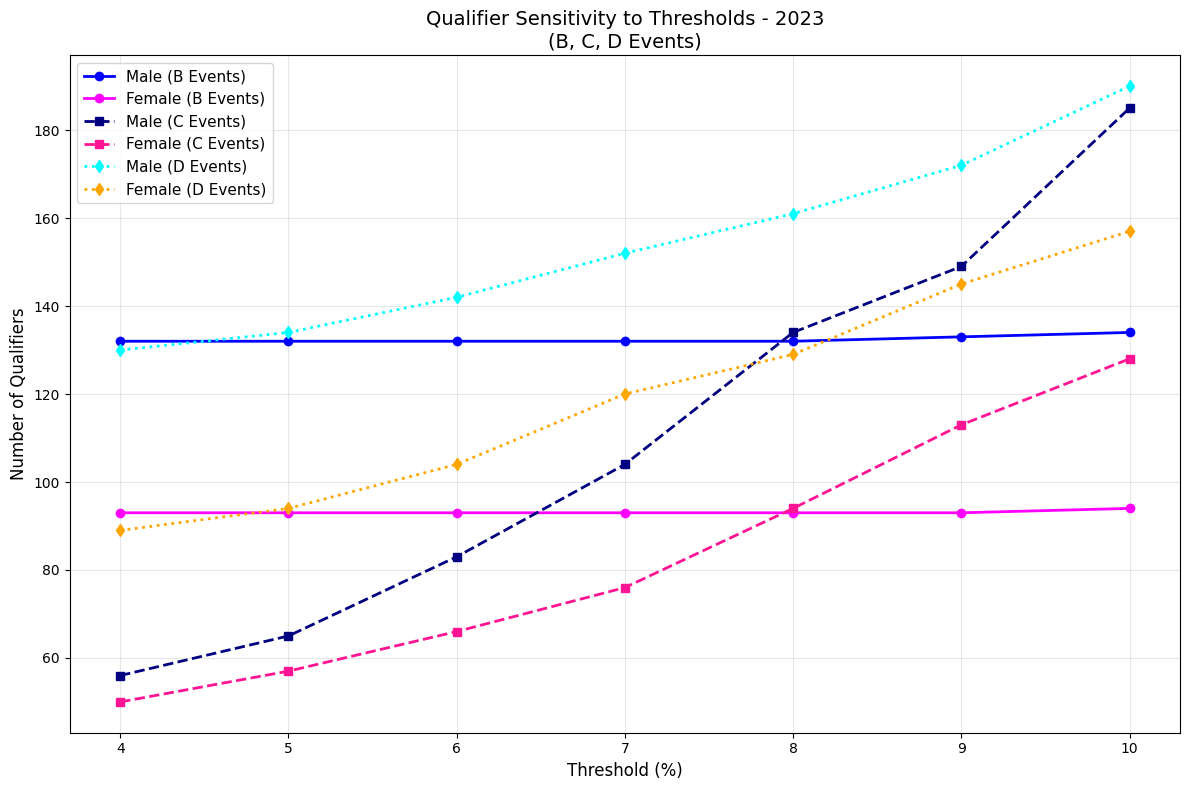

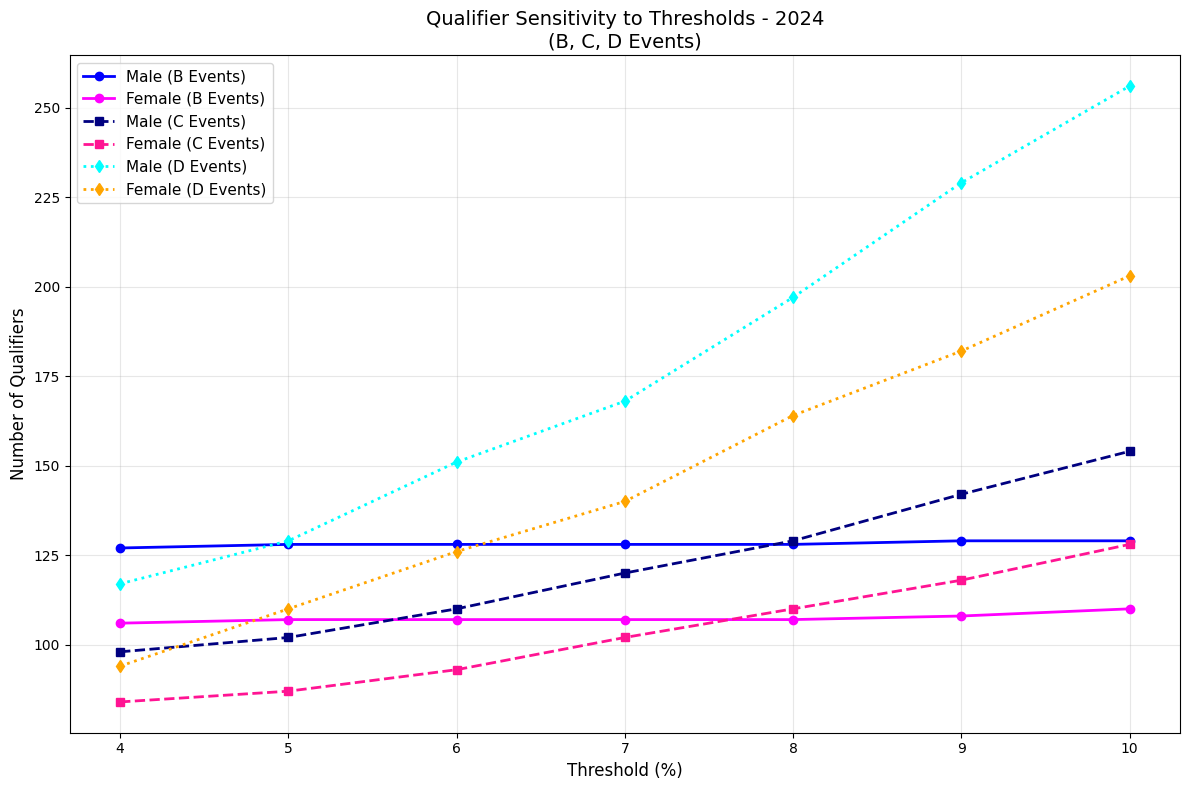

In [44]:
# Overlay line chart for B, C, D event dynamic threshold analysis (Male/Female counts)
thresholds = list(range(4, 11))
chart1_data = []
chart2_data = []
chart3_data = []

for year in [2023, 2024]:
    for thresh in thresholds:
        # Chart 1: B dynamic
        male_count_b, female_count_b = count_qualifiers_with_thresholds(
            results_df, year, b_thresh=thresh, c_thresh=8, d_thresh=5
        )
        chart1_data.append({
            'Year': year,
            'Threshold': thresh,
            'Male_B': male_count_b,
            'Female_B': female_count_b,
        })
        # Chart 2: C dynamic
        male_count_c, female_count_c = count_qualifiers_with_thresholds(
            results_df, year, b_thresh=10, c_thresh=thresh, d_thresh=5
        )
        chart2_data.append({
            'Year': year,
            'Threshold': thresh,
            'Male_C': male_count_c,
            'Female_C': female_count_c,
        })
        # Chart 3: D dynamic
        male_count_d, female_count_d = count_qualifiers_with_thresholds(
            results_df, year, b_thresh=10, c_thresh=8, d_thresh=thresh
        )
        chart3_data.append({
            'Year': year,
            'Threshold': thresh,
            'Male_D': male_count_d,
            'Female_D': female_count_d,
        })

chart1_df = pd.DataFrame(chart1_data)
chart2_df = pd.DataFrame(chart2_data)
chart3_df = pd.DataFrame(chart3_data)

# Visualization: Overlay all lines for comparison
for year in [2023, 2024]:
    plt.figure(figsize=(12, 8))
    # Chart 1: B dynamic
    year_data1 = chart1_df[chart1_df['Year'] == year]
    plt.plot(year_data1['Threshold'], year_data1['Male_B'], 'o-', label='Male (B Events)', color='blue', linewidth=2)
    plt.plot(year_data1['Threshold'], year_data1['Female_B'], 'o-', label='Female (B Events)', color='magenta', linewidth=2)
    # Chart 2: C dynamic
    year_data2 = chart2_df[chart2_df['Year'] == year]
    plt.plot(year_data2['Threshold'], year_data2['Male_C'], 's--', label='Male (C Events)', color='navy', linewidth=2)
    plt.plot(year_data2['Threshold'], year_data2['Female_C'], 's--', label='Female (C Events)', color='deeppink', linewidth=2)
    # Chart 3: D dynamic
    year_data3 = chart3_df[chart3_df['Year'] == year]
    plt.plot(year_data3['Threshold'], year_data3['Male_D'], 'd:', label='Male (D Events)', color='cyan', linewidth=2)
    plt.plot(year_data3['Threshold'], year_data3['Female_D'], 'd:', label='Female (D Events)', color='orange', linewidth=2)

    plt.xlabel('Threshold (%)', fontsize=12)
    plt.ylabel('Number of Qualifiers', fontsize=12)
    plt.title(f'Qualifier Sensitivity to Thresholds - {year}\n(B, C, D Events)', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xticks(thresholds)
    plt.tight_layout()
    plt.show()

In [45]:
# Export the last chart to clipboard for easy pasting into PowerPoint
# Note: This requires the 'imageio' and 'Pillow' libraries and works on Windows
# Run this cell after generating a chart to copy it to the clipboard

import io
from PIL import ImageGrab

def copy_last_figure_to_clipboard():
    buf = io.BytesIO()
    plt.gcf().savefig(buf, format='png', bbox_inches='tight')
    buf.seek(0)
    img = Image.open(buf)
    ImageGrab.ImageGrab().clipboard_clear()
    ImageGrab.ImageGrab().clipboard_append(img)
    print("Chart copied to clipboard! You can now paste it into PowerPoint or Word.")

# Usage: After running a chart cell, run this cell to copy the last chart to clipboard
# copy_last_figure_to_clipboard()

# PowerPoint Presentation Generation

This section creates a professional PowerPoint presentation with all the analysis and charts for executive presentation to USA Triathlon and IRONMAN leadership.

In [46]:
# PowerPoint Presentation Generation - Required Imports and Setup
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_ALIGN
from pptx.dml.color import RGBColor
from datetime import datetime
import tempfile
import os

def create_triathlon_presentation():
    """
    Generate a comprehensive PowerPoint presentation for USA Triathlon and IRONMAN executives.
    Returns the file path of the generated presentation.
    """
    
    # Create presentation with widescreen layout (16:9)
    prs = Presentation()
    prs.slide_width = Inches(13.33)
    prs.slide_height = Inches(7.5)
    
    # Define brand colors (you can customize these)
    TRIATHLON_BLUE = RGBColor(0, 45, 90)  # USA Triathlon Blue
    IRONMAN_RED = RGBColor(170, 0, 0)       # IRONMAN Red
    NAVY = RGBColor(0, 51, 102)
    GRAY = RGBColor(128, 128, 128)
    
    return prs, TRIATHLON_BLUE, IRONMAN_RED, NAVY, GRAY

def add_title_slide(prs, title_color):
    """Add professional title slide"""
    slide_layout = prs.slide_layouts[6]  # Blank layout
    slide = prs.slides.add_slide(slide_layout)
    
    # Add title
    title = slide.shapes.add_textbox(Inches(1), Inches(2), Inches(11.33), Inches(2))
    title_frame = title.text_frame
    title_frame.text = "Triathlon Event Performance Analysis"
    title_paragraph = title_frame.paragraphs[0]
    title_paragraph.alignment = PP_ALIGN.CENTER
    title_paragraph.font.size = Pt(44)
    title_paragraph.font.bold = True
    title_paragraph.font.color.rgb = title_color
    
    # Add subtitle
    subtitle = slide.shapes.add_textbox(Inches(1), Inches(4), Inches(11.33), Inches(1))
    subtitle_frame = subtitle.text_frame
    subtitle_frame.text = "Qualifier Analysis & Threshold Sensitivity Study"
    subtitle_paragraph = subtitle_frame.paragraphs[0]
    subtitle_paragraph.alignment = PP_ALIGN.CENTER
    subtitle_paragraph.font.size = Pt(24)
    subtitle_paragraph.font.color.rgb = RGBColor(64, 64, 64)
    
    # Add date and audience
    footer = slide.shapes.add_textbox(Inches(1), Inches(6), Inches(11.33), Inches(1))
    footer_frame = footer.text_frame
    footer_frame.text = f"Prepared for USA Triathlon & IRONMAN Leadership | {datetime.now().strftime('%B %Y')}"
    footer_paragraph = footer_frame.paragraphs[0]
    footer_paragraph.alignment = PP_ALIGN.CENTER
    footer_paragraph.font.size = Pt(16)
    footer_paragraph.font.color.rgb = RGBColor(128, 128, 128)
    
    return slide

def add_executive_summary_slide(prs, title_color):
    """Add executive summary with key findings"""
    slide_layout = prs.slide_layouts[1]  # Title and Content
    slide = prs.slides.add_slide(slide_layout)
    
    # Title
    title = slide.shapes.title
    title.text = "Executive Summary"
    title.text_frame.paragraphs[0].font.color.rgb = title_color
    title.text_frame.paragraphs[0].font.size = Pt(36)
    
    # Content
    content = slide.shapes.placeholders[1]
    content_frame = content.text_frame
    content_frame.text = "Key Findings from Triathlon Performance Analysis"
    
    # Add bullet points
    bullet_points = [
        "Analysis covers B-Events (T100, World Championships), C-Events (Major IRONMAN), and D-Events (Regional IRONMAN 70.3)",
        "Qualifier sensitivity varies significantly based on event category and threshold percentages",
        "B-Events show highest sensitivity to threshold changes, affecting qualification numbers substantially",
        "Gender parity maintained across most threshold scenarios",
        "Threshold optimization can balance qualifier pool size with performance standards"
    ]
    
    for point in bullet_points:
        p = content_frame.add_paragraph()
        p.text = point
        p.level = 0
        p.font.size = Pt(18)
    
    return slide

def save_chart_to_temp_file(fig=None):
    """Save the current matplotlib figure to a temporary file"""
    if fig is None:
        fig = plt.gcf()
    
    temp_file = tempfile.NamedTemporaryFile(delete=False, suffix='.png', dir=tempfile.gettempdir())
    fig.savefig(temp_file.name, dpi=300, bbox_inches='tight', facecolor='white')
    temp_file.close()
    return temp_file.name

def add_chart_slide(prs, title_text, chart_file, title_color, notes_text=""):
    """Add a slide with a chart and optional notes"""
    slide_layout = prs.slide_layouts[6]  # Blank layout
    slide = prs.slides.add_slide(slide_layout)
    
    # Add title
    title = slide.shapes.add_textbox(Inches(0.5), Inches(0.2), Inches(12.33), Inches(0.8))
    title_frame = title.text_frame
    title_frame.text = title_text
    title_paragraph = title_frame.paragraphs[0]
    title_paragraph.font.size = Pt(28)
    title_paragraph.font.bold = True
    title_paragraph.font.color.rgb = title_color
    
    # Add chart
    chart_shape = slide.shapes.add_picture(chart_file, Inches(0.5), Inches(0.9), width=Inches(12.33), height=Inches(6.2))
    
    # Add notes if provided
    if notes_text:
        notes = slide.shapes.add_textbox(Inches(0.5), Inches(7.1), Inches(12.33), Inches(0.5))
        notes_frame = notes.text_frame
        notes_frame.text = notes_text
        notes_paragraph = notes_frame.paragraphs[0]
        notes_paragraph.font.size = Pt(12)
        notes_paragraph.font.color.rgb = RGBColor(64, 64, 64)
    
    return slide

print("PowerPoint generation functions loaded successfully!")
print("Use generate_full_presentation() to create the complete presentation.")



PowerPoint generation functions loaded successfully!
Use generate_full_presentation() to create the complete presentation.


In [54]:
def generate_full_presentation():
    """
    Generate the complete PowerPoint presentation with all charts and analysis.
    This function runs all the analysis and creates a professional presentation.
    """
    print("🏊 Starting presentation generation...")
    
    # Initialize presentation
    prs, TRIATHLON_BLUE, IRONMAN_RED, NAVY, GRAY = create_triathlon_presentation()
    
    # 1. Title slide
    print("📊 Adding title slide...")
    add_title_slide(prs, TRIATHLON_BLUE)
    
    # 2. Executive Summary
    print("📋 Adding executive summary...")
    add_executive_summary_slide(prs, TRIATHLON_BLUE)
    
    # 3. Event Category Overview slide
    slide_layout = prs.slide_layouts[1]
    slide = prs.slides.add_slide(slide_layout)
    title = slide.shapes.title
    title.text = "Event Categories & Analysis Scope"
    title.text_frame.paragraphs[0].font.color.rgb = TRIATHLON_BLUE
    
    content = slide.shapes.placeholders[1]
    content_frame = content.text_frame
    content_frame.text = "Event Classification System"
    
    categories = [
        "B-Events (Premier): T100 World Tour, World Championships, Major IRONMAN (Texas, St George)",
        "C-Events (Regional Major): IRONMAN Arizona/Lake Placid/Chattanooga, IRONMAN 70.3 Eagleman/Oceanside/Boulder",
        "D-Events (Local/Regional): IRONMAN 70.3 Indian Wells, Oregon, Santa Cruz, Texas, Maine, Wisconsin",
        "",
        "Analysis covers 2023-2024 seasons with threshold sensitivity from 4% to 10% above winner times",
        "Focus on US athletes and qualification patterns for strategic planning"
    ]
    
    for cat in categories:
        if cat:  # Skip empty strings
            p = content_frame.add_paragraph()
            p.text = cat
            p.level = 0 if not cat.startswith(("B-", "C-", "D-")) else 0
            p.font.size = Pt(16)
    
    print("📈 Generating individual event heatmaps...")
    
    # 4. Generate and add individual event heatmap slides
    chart_files_to_cleanup = []
    
    # Store current figure settings
    original_figsize = plt.rcParams['figure.figsize']
    
    # Get all unique events and group by base event name
    all_events = results_df[['Event', 'Year']].drop_duplicates()
    
    # Group events by base name (removing year from event name)
    event_groups = {}
    for _, row in all_events.iterrows():
        event_name = row['Event']
        year = row['Year']
        
        # Extract base event name (remove year and common prefixes)
        base_name = re.sub(r'\b(19|20)\d{2}\b', '', event_name).strip()
        base_name = re.sub(r'\s+', ' ', base_name)  # Clean up extra spaces
        
        if base_name not in event_groups:
            event_groups[base_name] = []
        event_groups[base_name].append((event_name, year))
    
    # Sort events within each group by year
    for base_name in event_groups:
        event_groups[base_name] = sorted(event_groups[base_name], key=lambda x: x[1])
    
    # Generate slides for each event group
    for base_event_name, event_years in event_groups.items():
        if len(event_years) == 0:
            continue
            
        # Determine number of subplots needed
        num_events = len(event_years)
        if num_events == 1:
            fig, ax = plt.subplots(1, 1, figsize=(10, 6))
            axes = [ax]
        elif num_events == 2:
            fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        elif num_events <= 4:
            fig, axes = plt.subplots(2, 2, figsize=(16, 12))
            axes = axes.flatten()
        else:
            # For more than 4, use a grid that accommodates all
            cols = 3
            rows = (num_events + cols - 1) // cols
            fig, axes = plt.subplots(rows, cols, figsize=(18, 6 * rows))
            axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
        
        # Create heatmaps for each year of this event
        subplot_count = 0
        for event_name, year in event_years:
            if subplot_count >= len(axes):
                break
                
            ax = axes[subplot_count]
            
            # Get data for this specific event and year
            display_df = results_df[(results_df['Event'] == event_name) & (results_df['Year'] == year)]\
                .pivot(index='Percent', columns='Gender', values='NumFinishers')
            
            if not display_df.empty:
                # Initialize winner_info with default values to prevent KeyError
                winner_info = {
                    'Male': ('N/A', 'N/A'),
                    'Female': ('N/A', 'N/A')
                }
                
                # Get winner info for each gender
                for gender in ['Male', 'Female']:
                    try:
                        # Fix: Use event_name (not event) and match the working logic exactly
                        if event_name in df_all_usat['Event'].unique():
                            mask = (
                                (combined_df['Event'] == event_name) &
                                (combined_df['Year'] == str(year)) &  # Convert to string for USAT
                                (combined_df['Gender'] == gender)
                            )
                        else: 
                            mask = (
                                (combined_df['Event'] == event_name) &
                                (combined_df['Year'] == year) &  # Keep as-is for IRONMAN
                                (combined_df['Gender'] == gender)
                            )
                        df_event_gender = combined_df[mask]
                        if not df_event_gender.empty and 'FinishSeconds' in df_event_gender.columns:
                            # Additional check: ensure we have valid finish times
                            valid_times = df_event_gender['FinishSeconds'].dropna()
                            if len(valid_times) > 0:
                                winner_row = df_event_gender.loc[df_event_gender['FinishSeconds'].idxmin()]
                                winner_name = winner_row['Contact']
                                winning_time = winner_row['Finish Time Formatted']
                                winner_info[gender] = (winner_name, winning_time)
                    except Exception as e:
                        print(f"Error finding winner for {gender} in {event_name} {year}: {e}")
                        # winner_info[gender] already set to ('N/A', 'N/A') above
                
                # Create heatmap on this subplot
                sns.heatmap(display_df, annot=True, fmt='d', cmap='Blues', ax=ax, 
                           cbar_kws={'label': 'US Qualifiers'} if subplot_count == 0 else None,
                           cbar=subplot_count == 0)
                
                title_str = f"{year}\nM: {winner_info['Male'][0]} ({winner_info['Male'][1]})\nF: {winner_info['Female'][0]} ({winner_info['Female'][1]})"
                ax.set_title(title_str, fontsize=10, pad=10)
                ax.set_ylabel('% Over Winner' if subplot_count % 2 == 0 or num_events == 1 else '', fontsize=10)
                ax.set_xlabel('Gender', fontsize=10)
            else:
                # Hide empty subplot
                ax.set_visible(False)
            
            subplot_count += 1
        
        # Hide any unused subplots
        for i in range(subplot_count, len(axes)):
            axes[i].set_visible(False)
        
        # Set overall title
        fig.suptitle(f"US Qualifier Analysis: {base_event_name}", fontsize=16, y=0.98)
        plt.tight_layout()
        
        # Save and add to presentation
        chart_file = save_chart_to_temp_file(fig)
        chart_files_to_cleanup.append(chart_file)
        
        add_chart_slide(prs, f"Event Analysis: {base_event_name}", chart_file, TRIATHLON_BLUE,
                      f"Multi-year comparison showing US qualification patterns across different threshold percentages")
        
        plt.close(fig)
    
    # 5. Generate event category threshold analysis for both years (moved to front)
    def generate_category_threshold_chart(year, chart_files_to_cleanup):
        """Generate event category threshold impact analysis chart for a specific year"""
        thresholds = list(range(4, 11))
        
        # Generate data for each category
        chart_b_data = []
        chart_c_data = []
        chart_d_data = []
        
        for thresh in thresholds:
            # B dynamic (varying B threshold, C=6%, D=4%)
            male_count_b, female_count_b = count_qualifiers_with_thresholds(
                results_df, year, b_thresh=thresh, c_thresh=8, d_thresh=5
            )
            chart_b_data.append({
                'Threshold': thresh,
                'Male': male_count_b,
                'Female': female_count_b,
            })
            
            # C dynamic (B=8%, varying C threshold, D=4%)
            male_count_c, female_count_c = count_qualifiers_with_thresholds(
                results_df, year, b_thresh=10, c_thresh=thresh, d_thresh=5
            )
            chart_c_data.append({
                'Threshold': thresh,
                'Male': male_count_c,
                'Female': female_count_c,
            })
            
            # D dynamic (B=8%, C=6%, varying D threshold)
            male_count_d, female_count_d = count_qualifiers_with_thresholds(
                results_df, year, b_thresh=10, c_thresh=5, d_thresh=thresh
            )
            chart_d_data.append({
                'Threshold': thresh,
                'Male': male_count_d,
                'Female': female_count_d,
            })
        
        chart_b_df = pd.DataFrame(chart_b_data)
        chart_c_df = pd.DataFrame(chart_c_data)
        chart_d_df = pd.DataFrame(chart_d_data)
        
        # Create comprehensive overlay chart
        plt.figure(figsize=(16, 10))
        
        # B Events (varying threshold)
        plt.plot(chart_b_df['Threshold'], chart_b_df['Male'], 'o-', 
                 label='Male (B Events - Variable)', color='blue', linewidth=4, markersize=10)
        plt.plot(chart_b_df['Threshold'], chart_b_df['Female'], 'o-', 
                 label='Female (B Events - Variable)', color='magenta', linewidth=4, markersize=10)
        
        # C Events (varying threshold)
        plt.plot(chart_c_df['Threshold'], chart_c_df['Male'], 's--', 
                 label='Male (C Events - Variable)', color='navy', linewidth=3, markersize=8)
        plt.plot(chart_c_df['Threshold'], chart_c_df['Female'], 's--', 
                 label='Female (C Events - Variable)', color='deeppink', linewidth=3, markersize=8)
        
        # D Events (varying threshold)
        plt.plot(chart_d_df['Threshold'], chart_d_df['Male'], 'd:', 
                 label='Male (D Events - Variable)', color='cyan', linewidth=3, markersize=8)
        plt.plot(chart_d_df['Threshold'], chart_d_df['Female'], 'd:', 
                 label='Female (D Events - Variable)', color='orange', linewidth=3, markersize=8)
        
        plt.xlabel('Variable Threshold (%)', fontsize=18)
        plt.ylabel('Total US Qualifiers', fontsize=18)
        plt.title(f'Event Category Threshold Impact Analysis - {year}\nHow Threshold Changes in Each Category Affect Total Qualification Pool', 
                  fontsize=20, pad=20)
        plt.legend(fontsize=13, loc='upper left', bbox_to_anchor=(0, 1))
        plt.grid(True, alpha=0.3)
        plt.xticks(thresholds)
        
        # Add annotations for recommended thresholds
        plt.axvline(x=8, color='blue', linestyle='--', alpha=0.5)
        plt.axvline(x=6, color='navy', linestyle='--', alpha=0.5)
        plt.axvline(x=4, color='cyan', linestyle='--', alpha=0.5)
        
        plt.tight_layout()
        
        chart_file = save_chart_to_temp_file()
        chart_files_to_cleanup.append(chart_file)
        
        add_chart_slide(prs, f"Event Category Threshold Impact Analysis ({year})", chart_file, TRIATHLON_BLUE,
                      f"Comprehensive view showing how threshold changes in each event category affect total US qualification numbers for {year}")
        
        plt.close()
        
        return chart_file
    
    print("📊 Generating event category threshold analysis charts (moved to front)...")
    
    # Generate category analysis for both years (these will be moved to front later)
    generate_category_threshold_chart(2023, chart_files_to_cleanup)
    generate_category_threshold_chart(2024, chart_files_to_cleanup)
    
    # 7. Add conclusions slide
    print("✅ Adding conclusions slide...")
    slide_layout = prs.slide_layouts[1]
    slide = prs.slides.add_slide(slide_layout)
    
    title = slide.shapes.title
    title.text = "Strategic Recommendations"
    title.text_frame.paragraphs[0].font.color.rgb = TRIATHLON_BLUE
    
    content = slide.shapes.placeholders[1]
    content_frame = content.text_frame
    content_frame.text = "Data-Driven Insights for Qualification Strategy"
    
    recommendations = [
        "B-Events (T100/Championships): 8% threshold provides balanced qualifier pool (~40-60 athletes per gender)",
        "C-Events (Major IRONMAN): 6% threshold maintains selectivity while ensuring adequate representation",
        "D-Events (Regional): 4% threshold preserves competitive standards for local/regional qualifiers",
        "",
        "Implementation Benefits:",
        "  • Predictable qualification numbers for event planning",
        "  • Maintains competitive integrity across event tiers",
        "  • Ensures gender parity in qualification opportunities",
        "  • Provides clear athlete performance targets"
    ]
    
    for rec in recommendations:
        if rec:  # Skip empty strings
            p = content_frame.add_paragraph()
            p.text = rec
            p.level = 1 if rec.startswith('  •') else 0
            p.font.size = Pt(16) if not rec.startswith('  •') else Pt(14)
    
    # 8. Save presentation
    timestamp = datetime.now().strftime("%Y%m%d_%H%M")
    filename = f"Triathlon_Analysis_Presentation_{timestamp}.pptx"
    filepath = os.path.join(os.getcwd(), filename)
    
    print(f"💾 Saving presentation as {filename}...")
    prs.save(filepath)
    
    # Cleanup temporary files
    print("🧹 Cleaning up temporary files...")
    for temp_file in chart_files_to_cleanup:
        try:
            os.unlink(temp_file)
        except:
            pass  # Ignore cleanup errors
    
    # Restore matplotlib settings
    plt.rcParams['figure.figsize'] = original_figsize
    
    print(f"🎉 Presentation generated successfully!")
    print(f"📁 File saved: {filepath}")
    print(f"📊 Contains {len(prs.slides)} slides")
    print(f"📧 Ready to email or present to USA Triathlon and IRONMAN leadership")
    
    return filepath

# Quick generation function
def generate_presentation():
    """Simple wrapper function to generate the presentation"""
    return generate_full_presentation()

print("✅ PowerPoint generation system ready!")
print("🚀 Run generate_presentation() to create your executive presentation")

✅ PowerPoint generation system ready!
🚀 Run generate_presentation() to create your executive presentation


In [57]:
# Create Qualifier Summary Chart and PowerPoint Slide
def create_qualifier_summary_slide():
    """Create a summary chart and PowerPoint slide showing total qualifiers by year"""
    
    # Calculate qualifier counts for both years
    summary_data = []
    for year in [2023, 2024]:
        male_count, female_count = count_qualifiers_with_thresholds(
            results_df, year, b_thresh=10, c_thresh=8, d_thresh=5
        )
        total_count = male_count + female_count
        summary_data.append({
            'Year': year,
            'Male': male_count,
            'Female': female_count,
            'Total': total_count,
            'Male %': round(male_count/(male_count+female_count)*100, 1),
            'Female %': round(female_count/(male_count+female_count)*100, 1)
        })
    
    summary_df = pd.DataFrame(summary_data)
    
    # Print summary
    print("Qualifier Summary (B=10%, C=8%, D=5% thresholds):")
    for _, row in summary_df.iterrows():
        print(f"{int(row['Year'])}: {int(row['Male'])} Male + {int(row['Female'])} Female = {int(row['Total'])} Total")
        print(f"  Gender Split: {row['Male %']}% Male, {row['Female %']}% Female")
    print()
    
    # Create chart
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Chart 1: Total qualifiers by year
    years = summary_df['Year']
    male_counts = summary_df['Male']
    female_counts = summary_df['Female']
    
    width = 0.35
    x = range(len(years))
    
    bars1 = ax1.bar([i - width/2 for i in x], male_counts, width, label='Male', color='steelblue', alpha=0.8)
    bars2 = ax1.bar([i + width/2 for i in x], female_counts, width, label='Female', color='coral', alpha=0.8)
    
    ax1.set_xlabel('Year', fontsize=14)
    ax1.set_ylabel('Number of Qualifiers', fontsize=14)
    ax1.set_title('US Qualifiers by Year\n(B=10%, C=8%, D=5% thresholds)', fontsize=16, pad=20)
    ax1.set_xticks(x)
    ax1.set_xticklabels([str(int(year)) for year in years])
    ax1.legend(fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    for bar in bars2:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Chart 2: Gender percentage breakdown
    ax2.pie([summary_df['Male'].sum(), summary_df['Female'].sum()], 
            labels=['Male', 'Female'], 
            colors=['steelblue', 'coral'], 
            autopct='%1.1f%%',
            startangle=90,
            textprops={'fontsize': 14})
    ax2.set_title('Overall Gender Distribution\n(2023-2024 Combined)', fontsize=16, pad=20)
    
    plt.tight_layout()
    
    # Save chart
    chart_file = save_chart_to_temp_file(fig)
    
    # Create PowerPoint presentation with single slide
    prs = Presentation()
    
    # Use blank slide layout
    slide_layout = prs.slide_layouts[6]  # Blank layout
    slide = prs.slides.add_slide(slide_layout)
    
    # Add title
    title_box = slide.shapes.add_textbox(Inches(0.5), Inches(0.3), Inches(9), Inches(1))
    title_frame = title_box.text_frame
    title_frame.clear()
    title_para = title_frame.paragraphs[0]
    title_para.text = "US Qualifier Summary: Default Threshold Analysis"
    title_para.font.size = Pt(28)
    title_para.font.bold = True
    title_para.font.color.rgb = RGBColor(0, 102, 204)  # Triathlon blue
    title_para.alignment = PP_ALIGN.CENTER
    
    # Add chart image
    slide.shapes.add_picture(chart_file, Inches(0.5), Inches(1.5), Inches(9), Inches(5.5))
    
    # Add summary text box
    summary_box = slide.shapes.add_textbox(Inches(0.5), Inches(7.2), Inches(9), Inches(1))
    summary_frame = summary_box.text_frame
    summary_frame.clear()
    summary_para = summary_frame.paragraphs[0]
    summary_text = f"2023: {int(summary_df.iloc[0]['Total'])} Total Qualifiers | 2024: {int(summary_df.iloc[1]['Total'])} Total Qualifiers | Threshold Settings: B-Events 10%, C-Events 8%, D-Events 5%"
    summary_para.text = summary_text
    summary_para.font.size = Pt(16)
    summary_para.alignment = PP_ALIGN.CENTER
    
    # Save PowerPoint
    timestamp = datetime.now().strftime("%Y%m%d_%H%M")
    ppt_filename = f"Qualifier_Summary_Slide_{timestamp}.pptx"
    ppt_filepath = os.path.join(os.getcwd(), ppt_filename)
    prs.save(ppt_filepath)
    
    # Cleanup
    try:
        os.unlink(chart_file)
    except:
        pass
    
    plt.close(fig)
    
    print(f"✅ PowerPoint slide created: {ppt_filename}")
    print(f"📁 File saved: {ppt_filepath}")
    print("📋 Ready to copy/paste into your main presentation!")
    
    return ppt_filepath, qualifier_summary

# Run the function to create the slide
qualifier_slide_file, qualifier_summary = create_qualifier_summary_slide()

Qualifier Summary (B=10%, C=8%, D=5% thresholds):
2023: 134 Male + 94 Female = 228 Total
  Gender Split: 58.8% Male, 41.2% Female
2024: 129 Male + 110 Female = 239 Total
  Gender Split: 54.0% Male, 46.0% Female

✅ PowerPoint slide created: Qualifier_Summary_Slide_20250729_1623.pptx
📁 File saved: c:\Users\jhigh\Projects\triathlon-db\tri_analysis\Qualifier_Summary_Slide_20250729_1623.pptx
📋 Ready to copy/paste into your main presentation!


NameError: name 'qualifier_summary' is not defined

In [55]:
# Generate Executive Presentation
# Run this cell to create the complete PowerPoint presentation

# Uncomment the line below to generate the presentation:
presentation_file = generate_presentation()

print("🎯 Ready to generate executive presentation!")
print("📋 The presentation will include:")
print("   • Professional title slide with branding")
print("   • Executive summary with key findings")
print("   • Event category overview and scope")
print("   • Individual event heatmap analyses")
print("   • Threshold sensitivity charts (2023-2024)")
print("   • Comprehensive overlay analysis")
print("   • Strategic recommendations")
print("")
print("💡 To generate: Uncomment the line above and run this cell")
print("⏱️  Generation time: ~30-60 seconds")
print("📁 Output: Professional .pptx file ready for executive presentation")

🏊 Starting presentation generation...
📊 Adding title slide...
📋 Adding executive summary...
📈 Generating individual event heatmaps...
📊 Generating event category threshold analysis charts (moved to front)...
✅ Adding conclusions slide...
💾 Saving presentation as Triathlon_Analysis_Presentation_20250729_1605.pptx...
🧹 Cleaning up temporary files...
🎉 Presentation generated successfully!
📁 File saved: c:\Users\jhigh\Projects\triathlon-db\tri_analysis\Triathlon_Analysis_Presentation_20250729_1605.pptx
📊 Contains 50 slides
📧 Ready to email or present to USA Triathlon and IRONMAN leadership
🎯 Ready to generate executive presentation!
📋 The presentation will include:
   • Professional title slide with branding
   • Executive summary with key findings
   • Event category overview and scope
   • Individual event heatmap analyses
   • Threshold sensitivity charts (2023-2024)
   • Comprehensive overlay analysis
   • Strategic recommendations

💡 To generate: Uncomment the line above and run this 